<a href="https://colab.research.google.com/github/Pablouski7/clustering_n_rag_u_index/blob/main/notebooks/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Muestra de artículos de prensa (2019–2026) — EDA, clustering y embeddings

Pipeline completo sobre `data/raw/stratified_grid_2019_2026.csv` (~28,777 artículos de
**Diario Expreso**, **El Universo** y **Primicias**), en cinco secciones:

1. **EDA** — análisis exploratorio sobre el texto **crudo**: calidad, artefactos de
   PressReader, longitudes, cobertura año × periódico, secciones, serie temporal y flags.
2. **Data Wrangling** — todas las transformaciones: normalización por campo,
   deduplicación, **sección canónica** (label para el clustering) y descarte de artículos
   de ≤40 palabras.
3. **Embeddings** — tres métodos texto → vector sobre el corpus ya limpio, y su
   visualización en 3D con **PCA** y **UMAP**.
4. **Clustering** — **HDBSCAN** sobre cada método, con métricas internas y externas
   contra la sección canónica.
5. **AE / VAE** — reducción de dimensión sobre los embeddings (exploratorio).

Métodos de embedding:

| Método | Dims | Cómo cubre el artículo |
|---|---:|---|
| **Doc2Vec** (gensim, PV-DBOW) | 150 | bolsa de palabras, sin límite de contexto |
| **BGE-M3** vía vLLM (servidor H200) | 1024 | un solo forward (ventana 8,192 tokens) |
| **BETO** (`dccuchile/bert-base-spanish-wwm-cased`) | 768 | ventanas solapadas de 512 tokens + pooling |

**Nota de comparabilidad:** los tres ven el **artículo completo**, cada uno por su
mecanismo. Al igualar la cantidad de texto, cualquier diferencia observada apunta al modelo
y su mecanismo de cobertura, no a cuánto texto vio cada uno.


In [1]:
%cd /home/pherrera/projects/clustering_n_rag_u_index/notebooks
%pwd

/home/pherrera/projects/clustering_n_rag_u_index/notebooks


'/home/pherrera/projects/clustering_n_rag_u_index/notebooks'

In [2]:
import sys
from pathlib import Path

# Ancla la raíz del repo esté donde esté el kernel (local o Colab)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

In [3]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Raíz del repo en el path (para importar src.llm_clients, como en scripts/check_vllm.py)
sys.path.insert(0, str(Path.cwd().parent))

# Paleta categórica fija por periódico (orden alfabético estable)
PALETA = ["#0057ff", "#00d84a", "#ff2bd6"]  # azul intenso, verde intenso, magenta intenso
COLOR_FLAG = {0: "#8f8a7a", 1: "#ff1a1a"}   # gris más profundo / rojo intenso

sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42

---
# 1. EDA

Análisis exploratorio **sin modificar los datos**: todo lo que sigue se mide sobre el texto
tal como llega del CSV. Las correcciones que este análisis justifica se aplican después, en
la sección 2 (Data Wrangling).


## Carga y tipos


In [4]:
data = pd.read_csv(RAIZ / "data" / "raw" / "stratified_grid_2019_2026.csv")
data

,id_articulo,id_pressreader,titulo,texto,seccion,seccion_canonica,fecha,id_periodico,nombre_periodico,anio,incertidumbre,economic_uncertainty,political_uncertainty,icor_index,icor_v2_index,icor_v3_1_index
0,109787,NaN,No Trabajan Y Quieren Sueldo,"Gabriela Rivadeneira, Soledad Buendía, Carlos ...",Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,1,1
1,109788,NaN,El 11 De Noviembre Estaría Listo El Informe De...,El destino de la reforma tributaria del Ejecut...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
2,109789,NaN,Las Enmiendas Constitucionales Aterrizan En Un...,Otra comisión en la Asamblea Nacional. El Cons...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
3,109790,NaN,El Ejecutivo Defiende El Veto Al Código Orgáni...,El Gobierno retoma la estrategia de explicar s...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
4,109791,NaN,Ecuador Quiere Enganchar A Los Turistas Paragu...,Representantes de empresas turísticas del Ecua...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28772,302988,NaN,Cinco Frutas Exóticas Y Milagrosas De La Amazo...,¿Sabía que la chonta puede ayudar a controlar ...,Gastronomía,Vida y Estilo,2025-01-29,4,Primicias,2025,0,0,0,0,0,0
28773,309044,NaN,"El Ají, Parte Indiscutible De La Gastronomía E...",En enero se celebra el Día Internacional de la...,Gastronomía,Vida y Estilo,2025-01-31,4,Primicias,2025,0,0,0,0,0,0
28774,311137,NaN,"Roberto Ayala, Ganador De Masterchef Ecuador, ...","Conocido como 'El hombre Ayala', Roberto ganó ...",Gastronomía,Vida y Estilo,2025-02-03,4,Primicias,2025,0,0,0,0,0,0
28775,324194,NaN,Ecuador Ganó El Premio A La Mejor Cocina Latin...,"El reconocimiento fue entregado por H10, una d...",Gastronomía,Vida y Estilo,2025-02-08,4,Primicias,2025,0,0,0,0,0,0


In [5]:
data.columns.to_list()

['id_articulo',
 'id_pressreader',
 'titulo',
 'texto',
 'seccion',
 'seccion_canonica',
 'fecha',
 'id_periodico',
 'nombre_periodico',
 'anio',
 'incertidumbre',
 'economic_uncertainty',
 'political_uncertainty',
 'icor_index',
 'icor_v2_index',
 'icor_v3_1_index']

In [6]:
data.drop(columns=["id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data.rename({"incertidumbre": "u_index",
            "economic_uncertainty": "economic_u_index",
            "political_uncertainty": "political_u_index",},
            axis=1, inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28777 entries, 0 to 28776
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_articulo        28777 non-null  int64 
 1   titulo             28777 non-null  object
 2   texto              28777 non-null  object
 3   seccion            28776 non-null  object
 4   seccion_canonica   28777 non-null  object
 5   fecha              28777 non-null  object
 6   nombre_periodico   28777 non-null  object
 7   anio               28777 non-null  int64 
 8   u_index            28777 non-null  int64 
 9   economic_u_index   28777 non-null  int64 
 10  political_u_index  28777 non-null  int64 
 11  icor_v3_1_index    28777 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 2.6+ MB


In [8]:
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = pd.to_datetime(data["anio"], format="%Y").dt.year
data["fecha"], data["anio"]

(0       2019-10-23
 1       2019-10-23
 2       2019-10-23
 3       2019-10-23
 4       2019-10-23
            ...    
 28772   2025-01-29
 28773   2025-01-31
 28774   2025-02-03
 28775   2025-02-08
 28776   2025-07-16
 Name: fecha, Length: 28777, dtype: datetime64[ns],
 0        2019
 1        2019
 2        2019
 3        2019
 4        2019
          ... 
 28772    2025
 28773    2025
 28774    2025
 28775    2025
 28776    2025
 Name: anio, Length: 28777, dtype: int32)

## Calidad de datos

Nulos, duplicados y consistencia básica antes de cualquier análisis.

In [9]:
print("Nulos por columna:")
print(data.isna().sum())
print(f"\nDuplicados por id_articulo: {data['id_articulo'].duplicated().sum()}")
print(f"Duplicados por (titulo, texto): {data.duplicated(subset=['titulo', 'texto']).sum()}")
print(f"Textos vacíos: {(data['texto'].str.strip().str.len() == 0).sum()}")
print(f"Rango de fechas: {data['fecha'].min().date()} → {data['fecha'].max().date()}")

Nulos por columna:
id_articulo          0
titulo               0
texto                0
seccion              1
seccion_canonica     0
fecha                0
nombre_periodico     0
anio                 0
u_index              0
economic_u_index     0
political_u_index    0
icor_v3_1_index      0
dtype: int64

Duplicados por id_articulo: 0
Duplicados por (titulo, texto): 0
Textos vacíos: 0
Rango de fechas: 2019-03-30 → 2026-07-09


## Análisis de calidad del texto

In [10]:
import re
import unicodedata
import collections
import pandas as pd


def diagnosticar_textos(df, col="texto", n_ejemplos=3, ancho=160):
    """Audita la columna de texto: prevalencia de artefactos conocidos + descubrimiento
    de codepoints no-ASCII no esperados. Solo reporta, no modifica nada."""
    t = df[col].fillna("").astype(str)
    N = len(t)

    # --- Patrones conocidos: (nombre, regex, es_grave) ---
    PATRONES = [
        ("Palabras pegadas (min.Mayus)", r"[a-záéíóúñ][.,;:!?][A-ZÁÉÍÓÚÑ]", True),
        ("Soft hyphen \\xad (parte palabras)", r"\xad", True),
        ("Pictogramas de recuadro", r"[■⬛◼◗❚❑►▶●◉‣]", True),
        ("Crucigrama (HORIZONTALES/VERTICALES)", r"HORIZONTALES|VERTICALES", True),
        ("Comillas tipográficas", r"[“”‘’«»]", False),
        ("Guiones tipográficos", r"[–—−]", False),
        ("Código sección final (I)/(O)/(E)", r"\(\s*[IOEFR]\s*\)\s*$", False),
        ("URLs", r"https?://|www\.", False),
        ("Emails", r"\b[\w.-]+@[\w.-]+\.\w+", False),
        ("Acentos combinantes (no-NFC)", r"[\u0300-\u036f]", False),
        ("Viñetas numeradas ≥6 (listas)", None, False),   # caso especial: conteo
        ("Runs de -- __ ..", r"[-_.]{4,}", False),
        ("Marker recuadro AL INICIO", r"^\s*[■⬛◼◗❚❑►▶●]", True),
        ("Dígito pegado a letra (12años)", r"\d[a-záéíóúñ]{3,}|[a-záéíóúñ]{4,}\d{4}", False),
    ]

    print(f"{'='*70}\nDIAGNÓSTICO — columna '{col}', {N:,} textos\n{'='*70}")
    print(f"{'PATRÓN':<40}{'DOCS':>8}{'%':>8}  GRAVE")
    print("-" * 70)
    hallazgos = {}
    for nombre, patron, grave in PATRONES:
        if patron is None:  # viñetas numeradas: umbral por conteo
            mask = t.str.count(r"\b\d+\.\s") >= 6
        else:
            mask = t.str.contains(patron, regex=True)
        n = int(mask.sum())
        hallazgos[nombre] = mask
        marca = "  🔴" if (grave and n) else ""
        print(f"{nombre:<40}{n:>8,}{n/N*100:>7.2f}%{marca}")

    # --- Duplicados ---
    dup_texto = int(df.duplicated(subset=[col], keep=False).sum())
    print("-" * 70)
    print(f"{'Textos duplicados exactos':<40}{dup_texto:>8,}{dup_texto/N*100:>7.2f}%")

    # --- DESCUBRIMIENTO: codepoints no-ASCII no esperados ---
    ESPERADOS = set("áéíóúñüÁÉÍÓÚÑÜ¿¡«»“”‘’–—−…■⬛◼◗❚❑►▶●")
    ESPERADOS |= set("çèãöëàäïô×øêâåºª°´²³©®™°")  # acentos/símbolos ya vistos
    cont = collections.Counter()
    for s in t:
        for ch in s:
            if ord(ch) > 127 and ch not in ESPERADOS and not unicodedata.combining(ch):
                cont[ch] += 1
    if cont:
        print(f"\n{'CODEPOINTS NO-ASCII INESPERADOS (posibles hallazgos nuevos)':^70}")
        print(f"{'CODEPOINT':<12}{'CAT':<5}{'OCURR':>8}{'DOCS':>7}  NOMBRE / ejemplo")
        print("-" * 70)
        for ch, oc in cont.most_common(25):
            docs = int(t.str.contains(re.escape(ch)).sum())
            nombre_u = unicodedata.name(ch, "?")
            print(f"U+{ord(ch):04X}{'':<6}{unicodedata.category(ch):<5}{oc:>8,}{docs:>7}  {nombre_u} {ch!r}")

    # --- Ejemplos concretos de los patrones graves ---
    print(f"\n{'='*70}\nEJEMPLOS (patrones graves)\n{'='*70}")
    for nombre, mask in hallazgos.items():
        graves = {p[0] for p in PATRONES if p[2]}
        if nombre not in graves or mask.sum() == 0:
            continue
        print(f"\n### {nombre} ({int(mask.sum()):,} docs)")
        for s in t[mask].head(n_ejemplos):
            frag = re.sub(r"\s+", " ", s).strip()
            print(f"  · {frag}")

    return hallazgos  # dict {patrón: máscara booleana} por si quieres filtrar con ellos

In [11]:
# El diagnóstico se ejecuta sobre titulo + seccion + texto: los artefactos no viven solo
# en el cuerpo (las etiquetas de sección casi duplican la cuenta de soft hyphens). El
# separador "\n" no crea falsos "palabras pegadas" en los bordes entre campos.
data["texto_diag"] = (data["titulo"].fillna("") + "\n"
                      + data["seccion"].fillna("") + "\n"
                      + data["texto"].fillna(""))
hallazgos = diagnosticar_textos(data, col="texto_diag")

DIAGNÓSTICO — columna 'texto_diag', 28,777 textos
PATRÓN                                      DOCS       %  GRAVE
----------------------------------------------------------------------
Palabras pegadas (min.Mayus)              13,611  47.30%  🔴
Soft hyphen \xad (parte palabras)          2,359   8.20%  🔴
Pictogramas de recuadro                      851   2.96%  🔴
Crucigrama (HORIZONTALES/VERTICALES)          32   0.11%  🔴
Comillas tipográficas                     12,325  42.83%
Guiones tipográficos                       1,361   4.73%
Código sección final (I)/(O)/(E)           3,293  11.44%
URLs                                         249   0.87%
Emails                                        96   0.33%
Acentos combinantes (no-NFC)                  10   0.03%
Viñetas numeradas ≥6 (listas)                215   0.75%
Runs de -- __ ..                              28   0.10%
Marker recuadro AL INICIO                    104   0.36%  🔴
Dígito pegado a letra (12años)               142   0.49%
--

### Diagnóstico de artefactos de texto (PressReader)

El texto proviene de PressReader y arrastra artefactos de maquetación que
**no son contenido** y degradan silenciosamente los embeddings (sobre todo en modelos
subword como BETO y BGE-M3, donde un carácter invisible a media palabra rompe la
tokenización). El diagnóstico se ejecuta sobre la concatenación `titulo + seccion + texto`,
para cubrir todo el material que llega al modelo (título y cuerpo se embeben juntos) más la
etiqueta de sección. Prevalencia medida sobre el corpus completo (28,777 artículos):

| Artefacto | Docs | % | Impacto |
|---|---:|---:|---|
| Palabras pegadas tras puntuación (`Lloret.En`) | 13,611 | 47.3% | Alto |
| Comillas tipográficas (`" " ' '`) | 12,325 | 42.8% | Bajo (cosmético) |
| Código de sección final `(I)`/`(O)`/`(E)` | 3,293 | 11.4% | Bajo |
| Soft hyphen `\xad` (parte palabras: `Actualidad`) | 2,359 | 8.2% | Alto |
| Guiones tipográficos (`– — −`) | 1,361 | 4.7% | Bajo |
| Pictogramas de recuadro (`■ ▶ ⬛ ◗ • ❏ ▪`) | 851 | 3.0% | Medio (ruido puro) |
| Dígito pegado a letra (`12años`) | 142 | 0.5% | Bajo |
| Crucigramas (`HORIZONTALES`/`VERTICALES`) | 32 | 0.1% | Alto (contenido no temático) |
| Private Use Area `\uF07D`, non-breaking hyphen `\u2011`, variation selectors `\uFE0F` | <10 c/u | — | Bajo |

**Observaciones clave:**

- **Los artefactos no viven solo en `texto`.** Al añadir `titulo` y `seccion` al diagnóstico,
  el soft hyphen casi se duplica (1,345 → 2,359 docs): las **etiquetas de sección vienen
  partidas** (`Actualidad`, `Diversión`). Esto no es cosmético: `seccion` alimenta la
  canonicalización de secciones, y `Actualidad` ≠ `Actualidad` haría
  cuente como dos. Por eso `seccion` también necesita al menos la limpieza de invisibles.
- El artefacto dominante son las **palabras pegadas** (47%): PressReader pierde el espacio tras
  el punto final de oración. Es corregible **solo** cuando queda punt
  palabras; la fracción pegada sin puntuación (`deImpuesto`, `mientraspermanecía`) es
  **irrecuperable** sin un segmentador y se delega en la tokenización subword del modelo.
- El **soft hyphen** (`\xad`, 95k ocurrencias) es el más traicionero:
  el tokenizer lo procesa y parte `primer` en subtokens espurios.
- Se detectó un carácter **Private Use Area** (`U+F07D`, categoría `C
  de la fuente de PressReader, sin significado Unicode → basura que se elimina.
- Los caracteres extranjeros detectados (`č ć š ž Ö Ç à ½ ₂`) son **contenido legítimo**
  (nombres eslavos/germánicos, fracciones, fórmulas) y **no** se tocan. No hay duplicados de
  texto (0 exactos).

## Longitud de los textos

In [12]:
# Longitudes sobre el texto CRUDO (aún sin normalizar). La sección 2 vuelve a medirlas
# tras la limpieza, y la comparación antes/después es en sí un resultado.
data["n_caracteres"] = data["texto"].str.len()
data["n_palabras"] = data["texto"].str.split().str.len()
data[["texto", "n_caracteres", "n_palabras"]].head(3)

,texto,n_caracteres,n_palabras
0,"Gabriela Rivadeneira, Soledad Buendía, Carlos ...",4654,740
1,El destino de la reforma tributaria del Ejecut...,1539,250
2,Otra comisión en la Asamblea Nacional. El Cons...,941,140


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

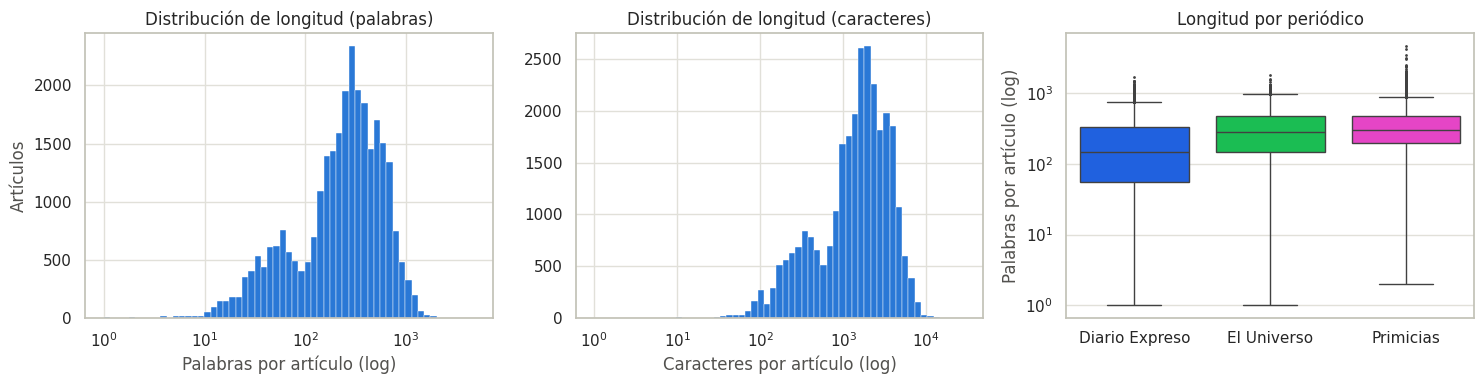

,n_palabras,n_caracteres
count,28777.0,28777.0
mean,316.0,1948.0
std,258.0,1583.0
min,1.0,1.0
25%,130.0,795.0
50%,263.0,1629.0
75%,443.0,2726.0
max,4746.0,29264.0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

bins_palabras = np.logspace(np.log10(data["n_palabras"].clip(lower=1).min()),
                            np.log10(data["n_palabras"].max()), 60)
axes[0].hist(data["n_palabras"], bins=bins_palabras, color="#2a78d6", edgecolor="white", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_xlabel("Palabras por artículo (log)")
axes[0].set_ylabel("Artículos")
axes[0].set_title("Distribución de longitud (palabras)")

bins_caracteres = np.logspace(np.log10(data["n_caracteres"].clip(lower=1).min()),
                              np.log10(data["n_caracteres"].max()), 60)
axes[1].hist(data["n_caracteres"], bins=bins_caracteres, color="#2a78d6", edgecolor="white", linewidth=0.3)
axes[1].set_xscale("log")
axes[1].set_xlabel("Caracteres por artículo (log)")
axes[1].set_title("Distribución de longitud (caracteres)")

orden_per = sorted(data["nombre_periodico"].unique())
sns.boxplot(data=data, x="nombre_periodico", y="n_palabras", order=orden_per,
            hue="nombre_periodico", hue_order=orden_per, palette=PALETA,
            legend=False, ax=axes[2], fliersize=1, linewidth=1)
axes[2].set_yscale("log")
axes[2].set_xlabel("")
axes[2].set_ylabel("Palabras por artículo (log)")
axes[2].set_title("Longitud por periódico")

plt.tight_layout()
plt.show()

data[["n_palabras", "n_caracteres"]].describe().round(0)

In [14]:
# Outliers en n_palabras según criterio IQR (1.5 * IQR)
q1 = data["n_palabras"].quantile(0.25)
q3 = data["n_palabras"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}")
print(f"Límites 'normales': [{limite_inferior:.0f}, {limite_superior:.0f}]")

outliers = data[(data["n_palabras"] < limite_inferior) | (data["n_palabras"] > limite_superior)]
print(f"\nTotal outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
print(f"  - por debajo (< {limite_inferior:.0f}): {(data['n_palabras'] < limite_inferior).sum()}")
print(f"  - por encima (> {limite_superior:.0f}): {(data['n_palabras'] > limite_superior).sum()}")

# Los más extremos por arriba (artículos larguísimos)
cols = [c for c in ["id_articulo", "titulo", "nombre_periodico", "seccion", "n_palabras", "n_caracteres"] if c in data.columns]
outliers.sort_values("n_palabras", ascending=False)[cols]


Q1=130  Q3=443  IQR=313
Límites 'normales': [-340, 912]

Total outliers: 856 (3.0%)
  - por debajo (< -340): 0
  - por encima (> 912): 856


,id_articulo,titulo,nombre_periodico,seccion,n_palabras,n_caracteres
22154,408727,Colombia | La Batalla Que Ganaron Las Big Tech...,Primicias,Política,4746,29264
5538,298581,20 Discos Que Siguen En La Memoria De Los Faná...,Primicias,Música,4273,25520
3511,435626,"Nvidia, La Mayor Empresa Del Mundo Por Capital...",Primicias,Ciencia-tecnologia,3513,21676
12239,228462,"Ibai Llanos, 'El Rey Midas De Internet', Diez ...",Primicias,Trending,3152,16858
17357,441666,"""Siempre Seremos Hijos De Europa"": ¿Por Qué El...",Primicias,Internacional,3066,19174
...,...,...,...,...,...,...
7997,460947,Estos Son Los Récords A Romper En El Mundial 2026,Primicias,Deportes,915,5352
22672,160260,Iess: Quejas Sin Resolver Hasta De Dos Décadas,Diario Expreso,Portada,914,5506
21421,167349,"Argentina, La Pieza Que Puede Reacomodar La Ge...",Primicias,Política,913,5617
25035,439799,Caso Malvinas | Cdh Acusa A Dos Fiscales Por P...,Primicias,Seguridad,913,5635


In [15]:
# Distribución fina de la cola baja: dimensiona cuántos artículos son teletipos, pies de
# foto o restos de maquetación. Motiva el umbral de descarte que se aplica en la sección 2.
for umbral in [5, 10, 20, 30, 40, 50, 60]:
    n = (data['n_palabras'] <= umbral).sum()
    print(f"<= {umbral:>3} palabras: {n:>5} artículos ({n/len(data)*100:.2f}%)")

print("\n--- Ejemplos de los más cortos ---")
cortos = data[data['n_palabras'] <= 50].sort_values('n_palabras').tail()
print(cortos[['n_palabras', 'texto']].to_string(index=False))

<=   5 palabras:    56 artículos (0.19%)
<=  10 palabras:   144 artículos (0.50%)
<=  20 palabras:   741 artículos (2.57%)
<=  30 palabras:  1571 artículos (5.46%)
<=  40 palabras:  2564 artículos (8.91%)
<=  50 palabras:  3450 artículos (11.99%)
<=  60 palabras:  4331 artículos (15.05%)

--- Ejemplos de los más cortos ---
 n_palabras                                                                                                                                                                                                                                                                                                                                                             texto
         50                                El primer semiconductor funcional hecho a partir de grafeno ha sido creado por investigadores de EE.UU. y China , una tecnología que podría permitir crear dispositivos más pequeños y rápidos, así como tener aplicaciones en computación cuántica. Expertos consideran q

## Cobertura muestral: año × periódico

Verificación del diseño estratificado (cuotas por estrato año × periódico).

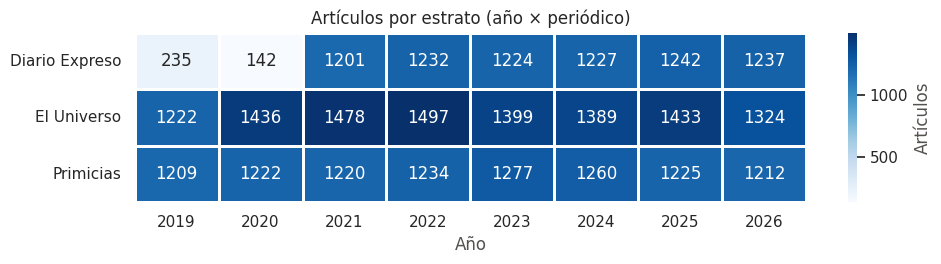

In [16]:
cobertura = data.pivot_table(index="nombre_periodico", columns="anio",
                             values="id_articulo", aggfunc="count", fill_value=0)

fig, ax = plt.subplots(figsize=(10, 2.8))
sns.heatmap(cobertura, annot=True, fmt="d", cmap="Blues", linewidths=2,
            linecolor="white", cbar_kws={"label": "Artículos"}, ax=ax)
ax.set_xlabel("Año")
ax.set_ylabel("")
ax.set_title("Artículos por estrato (año × periódico)")
plt.tight_layout()
plt.show()

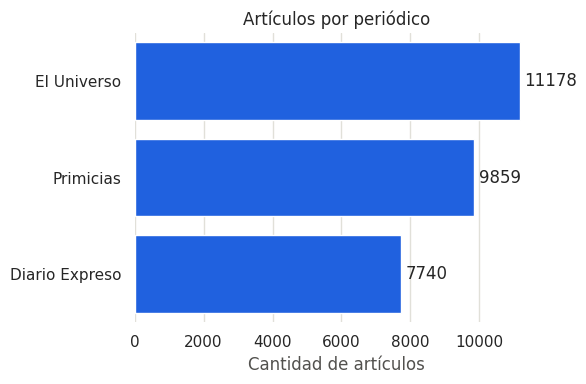

In [17]:
orden_per = data["nombre_periodico"].value_counts().index

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=data, y="nombre_periodico", order=orden_per, color=PALETA[0], ax=ax)
ax.set_xlabel("Cantidad de artículos")
ax.set_ylabel("")
ax.set_title("Artículos por periódico")

for cont in ax.containers:
    ax.bar_label(cont, padding=3)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## Secciones (crudas)

La sección viene como la titula cada periódico, así que es de **altísima cardinalidad**:
hay cientos de etiquetas distintas y la mayoría aparece en uno o dos artículos. Esto es
justo lo que motiva el mapeo a secciones canónicas de la sección 2 — como label de
clustering, la sección cruda es inservible.


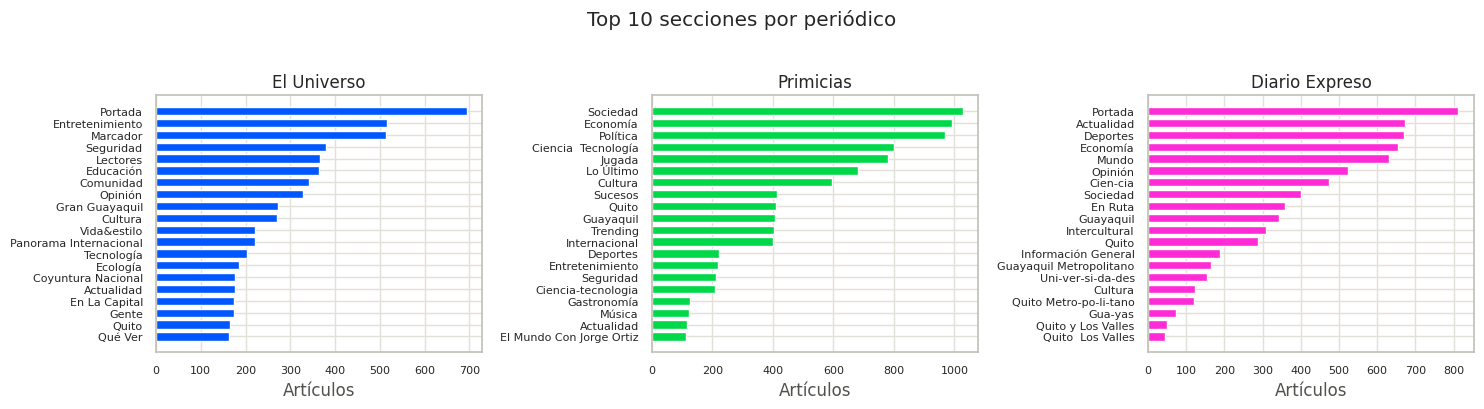

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, periodico, color in zip(axes, orden_per, PALETA):
    top = (data.loc[data["nombre_periodico"] == periodico, "seccion"]
           .value_counts().head(20).sort_values())
    ax.barh(top.index, top.values, color=color, height=0.7)
    ax.set_title(periodico)
    ax.set_xlabel("Artículos")
    ax.tick_params(labelsize=8)
plt.suptitle("Top 10 secciones por periódico", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Por periódico: nº de secciones que aparecen una sola vez ("únicas") frente al total
# de secciones distintas, para dimensionar la cola de etiquetas de un solo artículo.
resumen = []
for periodico in orden_per:
    vc = data.loc[data["nombre_periodico"] == periodico, "seccion"].value_counts()
    resumen.append({
        "periodico": periodico,
        "secciones_totales": vc.size,
        "secciones_unicas": int((vc == 1).sum()),
        "%_unicas": round(100 * (vc == 1).mean(), 1),
    })

resumen = pd.DataFrame(resumen).set_index("periodico")
resumen


,secciones_totales,secciones_unicas,%_unicas
periodico,,,
El Universo,1631,1096,67.2
Primicias,145,68,46.9
Diario Expreso,179,55,30.7


## Serie temporal: artículos por mes

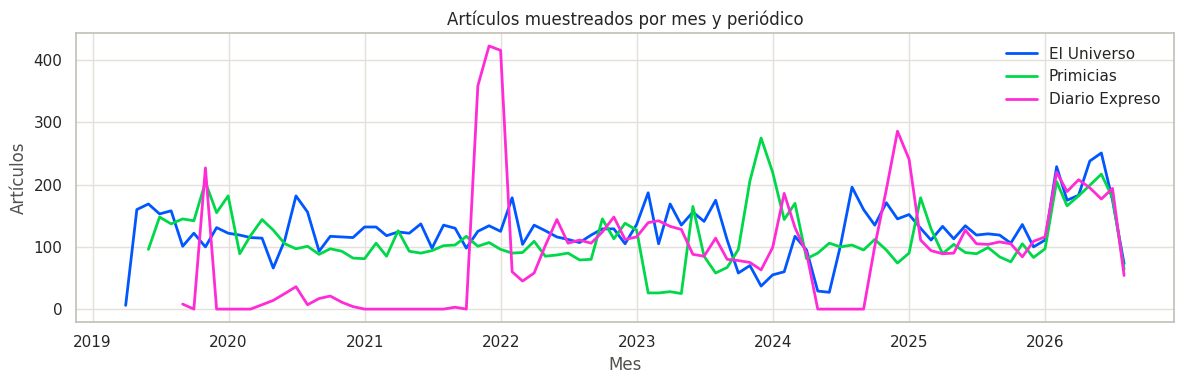

In [20]:
mensual = (data.set_index("fecha").groupby("nombre_periodico")
           .resample("ME")["id_articulo"].count().rename("articulos").reset_index())

fig, ax = plt.subplots(figsize=(12, 4))
for periodico, color in zip(orden_per, PALETA):
    serie = mensual[mensual["nombre_periodico"] == periodico]
    ax.plot(serie["fecha"], serie["articulos"], color=color, linewidth=2, label=periodico)
ax.set_xlabel("Mes")
ax.set_ylabel("Artículos")
ax.set_title("Artículos muestreados por mes y periódico")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Flags de incertidumbre y corrupción

- `u_index`, `economic_u_index`, `political_u_index`: flags de incertidumbre ya
  almacenadas en la BD de origen.
- `icor_v3_1_index`: flag de detección de corrupción (versión 3.1, con exclusión).

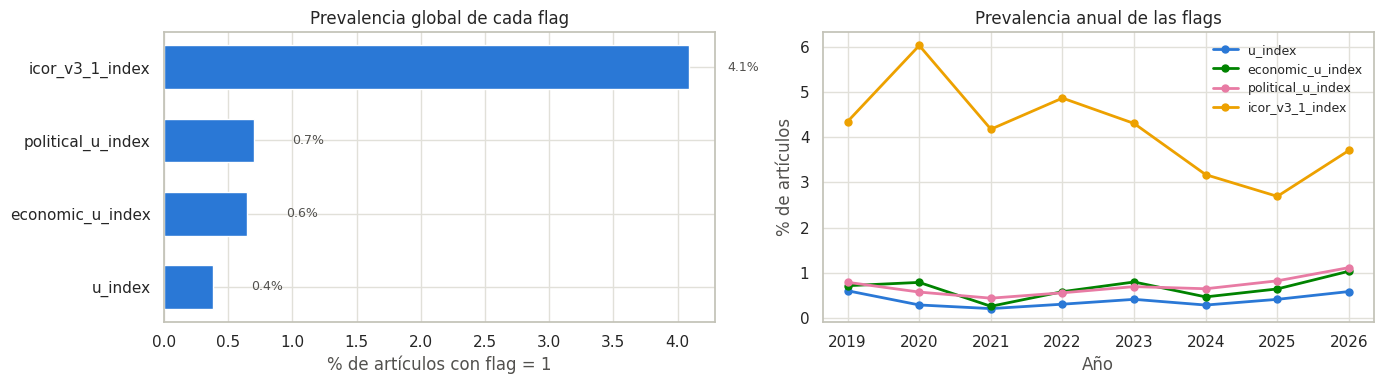

In [21]:
FLAGS = ["u_index", "economic_u_index", "political_u_index", "icor_v3_1_index"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

prevalencia = data[FLAGS].mean().sort_values() * 100
axes[0].barh(prevalencia.index, prevalencia.values, color="#2a78d6", height=0.6)
for i, v in enumerate(prevalencia.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9, color="#52514e")
axes[0].set_xlabel("% de artículos con flag = 1")
axes[0].set_title("Prevalencia global de cada flag")

anual = data.groupby("anio")[FLAGS].mean() * 100
colores_flags = ["#2a78d6", "#008300", "#e87ba4", "#eda100"]
for flag, color in zip(FLAGS, colores_flags):
    axes[1].plot(anual.index, anual[flag], color=color, linewidth=2, marker="o",
                 markersize=5, label=flag)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("% de artículos")
axes[1].set_title("Prevalencia anual de las flags")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

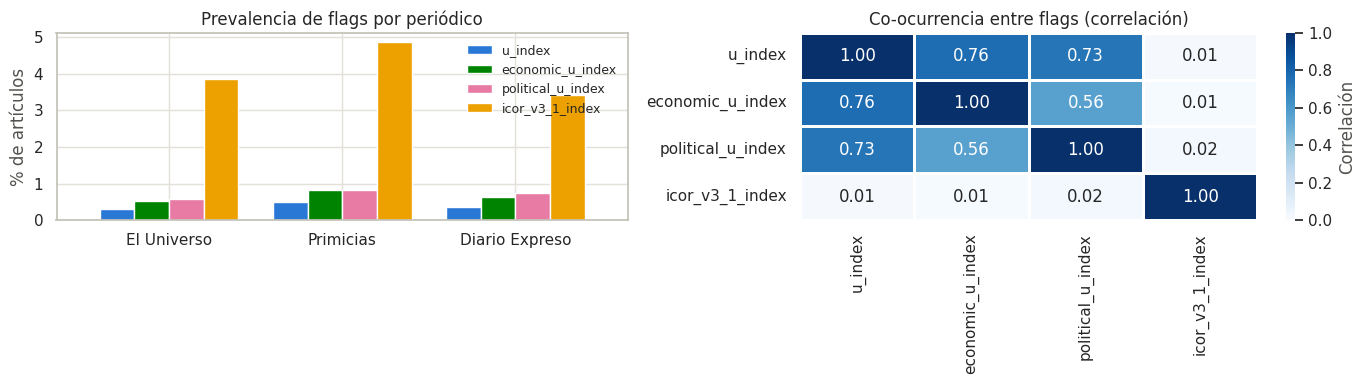

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

por_periodico = data.groupby("nombre_periodico")[FLAGS].mean().loc[orden_per] * 100
por_periodico.plot(kind="bar", ax=axes[0], color=colores_flags, width=0.8, edgecolor="white")
axes[0].set_xlabel("")
axes[0].set_ylabel("% de artículos")
axes[0].set_title("Prevalencia de flags por periódico")
axes[0].legend(frameon=False, fontsize=9)
axes[0].tick_params(axis="x", rotation=0)

sns.heatmap(data[FLAGS].corr(), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="white", ax=axes[1], cbar_kws={"label": "Correlación"})
axes[1].set_title("Co-ocurrencia entre flags (correlación)")

plt.tight_layout()
plt.show()

---
# 2. Data Wrangling

Aquí se aplican, en orden, todas las transformaciones que el EDA justificó:

1. **Normalización por campo** (limpieza de carácter).
2. **Deduplicación** sobre el texto normalizado.
3. **Sección canónica**: colapsa las secciones crudas a ~17 macro-secciones, que serán el
   label de referencia del clustering.
4. **Descarte de artículos de ≤40 palabras**.

A partir de aquí `data` **sí** se modifica; el EDA de arriba ya no es reproducible sobre el
`data` resultante.


## Normalización de texto

### Diseño de la normalización

La normalización se restringe a **limpieza de carácter**; los descartes por contenido
(crucigramas, artículos demasiado cortos) se hacen aparte, por fila. Se aplica **por campo**,
porque no todos alimentan lo mismo:

- `titulo` y `texto` se **embeben** (entran como `titulo + ". " + texto` al modelo) → reciben
  la normalización completa (`norm_text`).
- `seccion` es una **etiqueta categórica** que alimenta la canonicalización, no el modelo →
  recibe una versión ligera (`norm_label`): quita invisibles y recompone Unicode, pero **no**
  repara palabras pegadas ni pictogramas (irrelevante en una etiqueta), para no alterar el
  valor que se agrupa.

`norm_text` ejecuta, en orden deliberado (cada paso asume el anterior):

1. **Borrar caracteres invisibles/sin sentido:** soft hyphen (`\xad`), variation selectors
   (`\uFE0E\uFE0F`), zero-width y **Private Use Area** (`\uE000–\uF8FF`). Se eliminan (no se
   reemplazan por espacio) para volver a unir la palabra partida (`Actualidad → Actualidad`).
2. **Non-breaking hyphen (`\u2011`) → guión normal (`-`).**
3. **Normalización Unicode `NFC`** (no `NFKC`): recompone acentos descompuestos sin alterar
   comillas, `ñ`, ordinales ni cifras. `NFKC` se descartó porque convertiría `²`, `º`,
   ligaduras y fracciones, alterando datos numéricos legítimos sin beneficio aquí.
4. **Pictogramas de maquetación → espacio.** El `■`/`▶` aparecen también a media frase
   (`CULTURA■ Está preso`), así que se sustituyen por espacio, no se borran, para no volver a
   pegar palabras.
5. **Reparar palabras pegadas: `min.Mayus → min. Mayus`.** El patrón exige
   *minúscula + puntuación + Mayúscula*, lo que evita romper siglas (`FF.AA`), decimales
   (`4.759`) y dominios (`.com`). Es el paso con mayor superficie de error, por eso se acota al
   caso inequívoco.
6. **Minúsculas y colapso de espacios** (`\s+ → " "`), al final, para absorber los espacios
   que introdujeron los pasos 4 y 5.

**Lo que NO se normaliza (por diseño):** comillas y guiones tipográficos (cosmético para
tokenizers subword), el código `(I)/(O)` final (inofensivo tras minúsculas) y las palabras
pegadas sin puntuación (irrecuperables). Tras aplicar la función, re-ejecutar el diagnóstico
sobre el texto normalizado confirma que los invisibles y pictogramas caen a ~0; el residuo
esperado son esos tres casos.

In [23]:
import re
import unicodedata

# Pictogramas / viñetas de maquetación PressReader
_BASURA_PICTO = re.compile(r"[■⬛◼◗❚❑►▶▪●◉•‣·❏⬇◄▲▼★☆➤—―]")
# Invisibles / sin sentido: variation selectors, zero-width, direccionales y Private Use Area
_INVISIBLES = re.compile(r"[\uFE0E\uFE0F\u200B-\u200F\u202A-\u202E\uE000-\uF8FF]")


def _limpiar_invisibles(text: str) -> str:
    """Paso común: quita caracteres invisibles/sin sentido y recompone Unicode (NFC)."""
    text = text.replace("\xad", "")           # soft hyphen -> une palabra partida
    text = text.replace("\u2011", "-")        # non-breaking hyphen -> guión normal
    text = _INVISIBLES.sub("", text)          # variation selectors, zero-width, PUA (\uF07D)
    return unicodedata.normalize("NFC", text) # acentos descompuestos; NO altera comillas/ñ


def norm_text(text: str) -> str:
    """Normalización completa para contenido que se embebe (titulo, texto)."""
    text = _limpiar_invisibles(text)
    text = _BASURA_PICTO.sub(" ", text)                                      # pictogramas -> espacio
    text = re.sub(r"([a-záéíóúñ])([.,;:!?])([A-ZÁÉÍÓÚÑ])", r"\1\2 \3", text)  # min.Mayus -> min. Mayus
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def norm_label(text: str) -> str:
    """Normalización ligera para etiquetas categóricas (seccion): sin reparar pegados/pictos."""
    text = _limpiar_invisibles(text)
    text = _BASURA_PICTO.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


# --- Aplicación por campo ---
data["titulo_norm"]  = data["titulo"].fillna("").map(norm_text)
data["texto_norm"]   = data["texto"].map(norm_text)
data["seccion"]      = data["seccion"].fillna("").map(norm_label)  # antes de seccion_canonica


data["texto_diag"] = (data["titulo_norm"] + "\n" + data["seccion"] + "\n" + data["texto_norm"])
_ = diagnosticar_textos(data, col="texto_diag")

DIAGNÓSTICO — columna 'texto_diag', 28,777 textos
PATRÓN                                      DOCS       %  GRAVE
----------------------------------------------------------------------
Palabras pegadas (min.Mayus)                   0   0.00%
Soft hyphen \xad (parte palabras)              0   0.00%
Pictogramas de recuadro                        0   0.00%
Crucigrama (HORIZONTALES/VERTICALES)           0   0.00%
Comillas tipográficas                     12,325  42.83%
Guiones tipográficos                         976   3.39%
Código sección final (I)/(O)/(E)               0   0.00%
URLs                                         250   0.87%
Emails                                       102   0.35%
Acentos combinantes (no-NFC)                   0   0.00%
Viñetas numeradas ≥6 (listas)                214   0.74%
Runs de -- __ ..                              28   0.10%
Marker recuadro AL INICIO                      0   0.00%
Dígito pegado a letra (12años)               475   1.65%
-----------------

In [24]:
print("Duplicados tras normalizar:", int(data.duplicated(subset=["titulo_norm","texto_norm"]).sum()))

Duplicados tras normalizar: 1


In [25]:
data = data.drop_duplicates(subset=["titulo_norm","texto_norm"]).reset_index(drop=True)

In [26]:
data.drop(columns=["texto_diag"], inplace=True)

## Sección canónica

La sección cruda tiene ~1,700 valores distintos en esta muestra (~7,400 en la BD completa),
la mayoría con 1-3 artículos: no se puede usar como clase ni balancear. El mapeo canónico
la colapsa a **17 macro-secciones** mediante reglas por palabra clave sobre el nombre
normalizado, evaluadas en orden (la primera que matchea gana).

La lógica es una copia literal de
`scripts/sampling_for_clustering/sample_balanced_by_seccion.py` (`normalizar_seccion`,
`_REGLAS`, `mapear_seccion_canonica`). Se **copia y no se importa** porque ese script
depende de `config.get_sqlalchemy_url` y `src.utilities.text_utils`, módulos que no existen
en este repositorio.

**Por qué recalcularla aquí si el CSV ya la trae:** la columna `seccion_canonica` del CSV
viene precocinada por el script de muestreo, contra la sección **cruda** de la BD. Traer la
lógica al notebook la vuelve **auditable y afinable** — sin esto, el ~6-7% que cae en
`Otros` no se puede mejorar sin volver a la base de datos. La celda de verificación mide
si recalcularla sobre la sección ya normalizada cambia algo (no debería: `normalizar_seccion`
aplica NFKC + minúsculas y matchea por substring, así que ya absorbe soft hyphens y
pictogramas por su cuenta).

Nota: `Portada`, `Opinión` y `Actualidad` no son temas sino formato o posición en el
periódico, y `Otros` es un cajón de sastre. La sección 4 reporta las métricas con y sin
estas cuatro clases.


In [27]:
# --- Mapeo canónico de sección ---
# Copia literal de scripts/sampling_for_clustering/sample_balanced_by_seccion.py
# (normalizar_seccion, _REGLAS, mapear_seccion_canonica). Ver nota arriba sobre por qué se
# copia en vez de importarse.
import re
import unicodedata


def normalizar_seccion(s: str) -> str:
    """Normaliza el nombre de sección para el matching de reglas.

    Quita soft-hyphens, aplica NFKC, unifica separadores (& -> ' y ', '-' -> ' '),
    colapsa espacios y pasa a minúsculas.
    """
    if not isinstance(s, str):
        return ""
    s = s.replace("\xad", "")  # soft-hyphen
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("&", " y ").replace("-", " ")
    return re.sub(r"\s+", " ", s).strip().lower()


# Reglas por palabra clave (substring sobre el nombre normalizado). Orden = prioridad:
# la primera que matchea gana. Cubren la cabeza y la cola larga.
_REGLAS = [
    ("Deportes", ("deporte", "jugada", "marcador", "futbol", "fútbol",
                  "eliminatoria", "mundial", "olimp",
                  "juegos", "liga", "copa")),
    ("Economía", ("económ", "economia", "economía", "negocio", "entorno económico",
                  "enfoque económico", "mercado", "finanz")),
    ("Política", ("polít", "politic", "legislat", "elecc", "asamblea",
                  "coyuntura nacional", "acontecer nacional", "hechos del país",
                  "debate", "gobierno", "presidencial")),
    ("Seguridad", ("segurid", "suceso", "delict", "violent", "muerte", "crimen",
                   "expediente", "narco", "conflicto")),
    ("Ciencia y Tecnología", ("ciencia", "tecnolog", "tecno", "digital", "innovac")),
    ("Vida y Estilo", ("vida y estilo", "vida estilo", "vidayestilo", "estilo",
                       "gastronom", "moda", "salud", "bienestar", "en ruta",
                       "hogar", "familia")),
    ("Cultura", ("cultura", "música", "musica", "cine", "arte", "libro",
                 "literatura", "gente", "patrimonio")),
    ("Entretenimiento", ("entreten", "farándula", "farandula", "trending", "diversión", "diversion",
                         "qué ver", "que ver", "espectác", "espectac", "tv",
                         "televisión", "viral")),
    ("Mundo", ("mundo", "internacional", "panorama internacional", "el país",
               "el mundo", "global", "migra")),
    ("Local Guayaquil", ("guayaquil", "guayas", "gran guayaquil")),
    ("Local Quito", ("quito", "capital", "los valles", "pichincha")),
    ("Educación", ("educ", "universidad", "escolar")),
    ("Sociedad", ("sociedad", "comunidad", "intercultural", "información general",
                  "informacion general", "ecología", "ecologia", "ambiente",
                  "en la ciudad")),
    # No temáticas (se evalúan al final para no capturar prefijos temáticos).
    ("Portada", ("portada",)),
    ("Opinión", ("opinión", "opinion", "lectores", "editorial", "columna")),
    ("Actualidad", ("actualidad", "lo último", "lo ultimo", "hoy", "última hora")),
]


def mapear_seccion_canonica(seccion: str) -> str:
    """Mapea una sección cruda a su sección canónica (o 'Otros')."""
    norm = normalizar_seccion(seccion)
    if not norm:
        return "Otros"
    for canonica, claves in _REGLAS:
        if any(clave in norm for clave in claves):
            return canonica
    return "Otros"

In [28]:
# Verificación: ¿recalcular la canónica sobre la sección ya normalizada cambia algo frente
# a la columna que trae el CSV? Se mide ANTES de sobrescribirla, para no perder la referencia.
canonica_regen = data["seccion"].map(mapear_seccion_canonica)
difieren = canonica_regen != data["seccion_canonica"]

print(f"Filas que cambian de clase al regenerar: {difieren.sum()} "
      f"({difieren.mean() * 100:.3f}%)")
if difieren.any():
    print("\nCasos que cambian (seccion -> del CSV / regenerada):")
    print(data.loc[difieren, ["seccion", "seccion_canonica"]]
          .assign(regenerada=canonica_regen[difieren])
          .value_counts().head(15).to_string())

data["seccion_canonica"] = canonica_regen

Filas que cambian de clase al regenerar: 107 (0.372%)

Casos que cambian (seccion -> del CSV / regenerada):
seccion    seccion_canonica  regenerada     
Diversión  Deportes          Entretenimiento    107


In [29]:
# Auditoría del mapeo: distribución por clase, cobertura fuera de 'Otros' y las secciones
# crudas que más caen en 'Otros' (es la lista para afinar _REGLAS sin salir del notebook).
conteos = data["seccion_canonica"].value_counts()
n_otros = conteos.get("Otros", 0)

print("Distribución por sección canónica:")
print(conteos.to_string())
print(f"\nClases: {conteos.size}  |  cobertura fuera de 'Otros': "
      f"{(len(data) - n_otros) / len(data) * 100:.1f}% "
      f"({len(data) - n_otros:,} de {len(data):,})")

otros_crudos = data.loc[data["seccion_canonica"] == "Otros", "seccion"].value_counts()
print(f"\nTop secciones crudas que caen en 'Otros' ({otros_crudos.size} distintas):")
print(otros_crudos.head(25).to_string())

Distribución por sección canónica:
seccion_canonica
Economía                2390
Sociedad                2361
Deportes                2317
Cultura                 2013
Otros                   2000
Mundo                   1865
Ciencia y Tecnología    1859
Actualidad              1761
Local Guayaquil         1657
Política                1632
Portada                 1507
Entretenimiento         1442
Local Quito             1396
Seguridad               1318
Vida y Estilo           1278
Opinión                 1231
Educación                749

Clases: 17  |  cobertura fuera de 'Otros': 93.0% (26,776 de 28,776)

Top secciones crudas que caen en 'Otros' (1104 distintas):
seccion
El Universo                        34
Especial                           25
Domingo                            22
Pasatiempos                        22
Patrocinado                        21
Front Page                         19
Garage                             19
Revistagestion                     16
Época Invernal

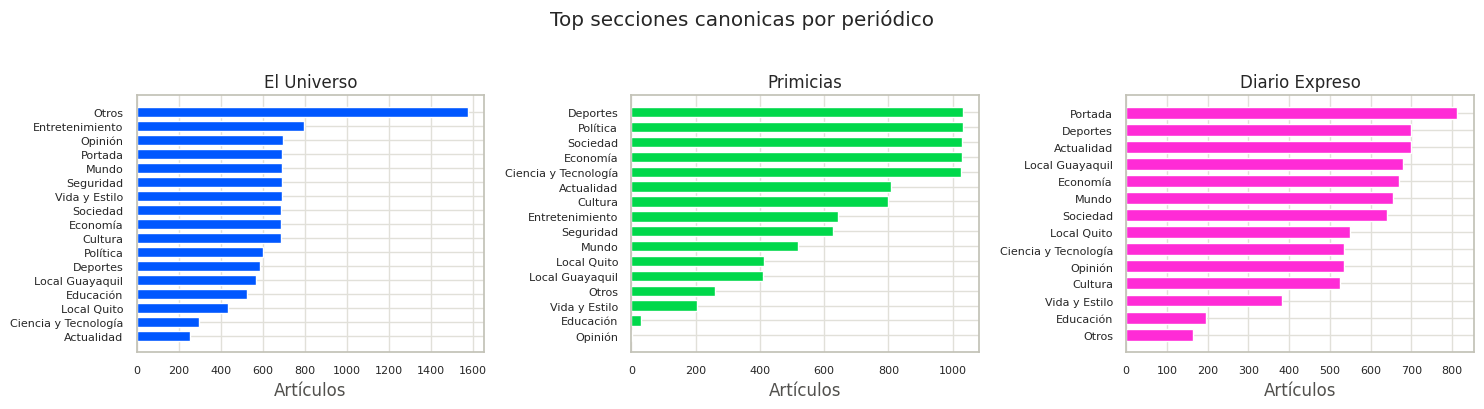

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, periodico, color in zip(axes, orden_per, PALETA):
    top = (data.loc[data["nombre_periodico"] == periodico, "seccion_canonica"]
           .value_counts().sort_values())
    ax.barh(top.index, top.values, color=color, height=0.7)
    ax.set_title(periodico)
    ax.set_xlabel("Artículos")
    ax.tick_params(labelsize=8)
plt.suptitle("Top secciones canonicas por periódico", y=1.02)
plt.tight_layout()
plt.show()

### La sección canónica como label del clustering

Estas 17 clases son la **referencia externa** con la que se evalúa el clustering en la
sección 4. Conviene ser explícito sobre qué son y qué no:

**Por qué sirven:**

- Es la **única etiqueta temática disponible** en el corpus. La alternativa, `seccion`
  cruda, tiene ~1,700 valores distintos y no se puede usar como clase.
- Tras el colapso quedan clases de **volumen comparable** (del orden de cientos a un par de
  miles de artículos cada una), porque `sample_grid_balanced.py` ya aplanó la sección
  dentro de cada celda año × periódico. Sin ese aplanado, el desbalance en el pool crudo
  llega a ~58×, y cualquier métrica supervisada estaría dominada por dos o tres clases.
- Permiten métricas **externas** (ARI, AMI, homogeneidad, completitud) que responden a la
  pregunta que importa: *¿la estructura que encuentra el clustering no supervisado se
  parece a la organización temática que hacen los periódicos?*

**Por qué NO son ground truth — y hay que decirlo al interpretar:**

- La etiqueta la asigna el periódico por criterio **editorial y de maquetación**, no por
  contenido: un mismo hecho puede ir en «Actualidad», en «Portada» o en la sección local
  según el día y el medio.
- El mapeo canónico es por **substring** sobre el nombre de página, así que hereda los
  errores de ese nombre y añade los suyos (una página «Mundial de fútbol» cae en Deportes,
  pero «Mundo» y «mundial» comparten prefijo con reglas distintas — de ahí que el orden de
  `_REGLAS` sea parte de la definición).
- Cuatro clases no son temas: `Portada` y `Actualidad` son posición o inmediatez,
  `Opinión` es género, `Otros` es residuo. Mezclan contenido heterogéneo por construcción.

**Consecuencia práctica:** un ARI bajo es ambiguo. Puede significar que el clustering
falló, o que encontró una partición temática **mejor** que la editorial. Por eso la sección
4 reporta las métricas en dos vistas —las 17 clases y solo las 13 temáticas— y acompaña
siempre las métricas externas con las internas y con el % de ruido.


## Descarte de artículos demasiado cortos

El EDA mostró una cola baja de artículos de pocas palabras: teletipos, pies de foto,
sumarios y restos de maquetación que no son artículos. Para embeddings y clustering son
ruido puro —un texto de 15 palabras produce un vector dominado por dos o tres términos— así
que se descartan los de **≤40 palabras**.

El umbral es una decisión de corte: 40 palabras es aproximadamente un titular más una
entradilla, el mínimo para que un embedding capture algo de tema. Se verifica abajo que el
descarte no se concentre en una sección o un periódico, lo que sesgaría el corpus.


In [31]:
# Longitudes sobre el texto YA normalizado (las del EDA eran sobre el crudo).
data["n_caracteres"] = data["texto_norm"].str.len()
data["n_palabras"] = data["texto_norm"].str.split().str.len()

MIN_PALABRAS = 40
descartados = data[data["n_palabras"] <= MIN_PALABRAS]
n_antes = len(data)

print(f"Artículos con <= {MIN_PALABRAS} palabras: {len(descartados):,} "
      f"({len(descartados) / n_antes * 100:.2f}%)")

# ¿El descarte sesga alguna clase? Se compara la tasa de descarte por grupo con la global.
tasa_global = len(descartados) / n_antes
for col in ["nombre_periodico", "seccion_canonica"]:
    tasa = (data.groupby(col)["n_palabras"].apply(lambda s: (s <= MIN_PALABRAS).mean())
            .sort_values(ascending=False) * 100)
    print(f"\n% descartado por {col} (global: {tasa_global * 100:.2f}%):")
    print(tasa.round(2).to_string())

print("\n--- Ejemplos de artículos descartados ---")
print(descartados[["n_palabras", "titulo", "texto_norm"]]
      .sort_values("n_palabras", ascending=False).head(5).to_string(index=False))

Artículos con <= 40 palabras: 2,566 (8.92%)

% descartado por nombre_periodico (global: 8.92%):
nombre_periodico
Diario Expreso    15.34
El Universo        9.26
Primicias          3.49

% descartado por seccion_canonica (global: 8.92%):
seccion_canonica
Educación               16.29
Vida y Estilo           15.18
Otros                   13.20
Sociedad                12.45
Local Guayaquil         12.37
Local Quito             11.89
Economía                11.13
Actualidad               8.52
Seguridad                7.81
Ciencia y Tecnología     7.75
Deportes                 7.73
Portada                  7.70
Mundo                    7.40
Entretenimiento          5.27
Cultura                  4.72
Política                 2.39
Opinión                  1.22

--- Ejemplos de artículos descartados ---
 n_palabras                                      titulo                                                                                                                                          

In [32]:
# `reset_index(drop=True)`: la sección 4 indexa con `data.iloc[i]` a partir de posiciones
# de los embeddings, así que el índice debe quedar 0..N-1 sin huecos.
data = data[data["n_palabras"] > MIN_PALABRAS].reset_index(drop=True)

print(f"Corpus limpio: {len(data):,} artículos (de {n_antes:,} antes del filtro)")
print(f"Secciones canónicas: {data['seccion_canonica'].nunique()} "
      f"| nulos: {int(data['seccion_canonica'].isna().sum())}")
print(f"\nLongitud tras la limpieza:")
print(data[["n_palabras", "n_caracteres"]].describe().round(0).to_string())

Corpus limpio: 26,210 artículos (de 28,776 antes del filtro)
Secciones canónicas: 17 | nulos: 0

Longitud tras la limpieza:
       n_palabras  n_caracteres
count     26210.0       26210.0
mean        347.0        2121.0
std         255.0        1550.0
min          41.0         209.0
25%         165.0        1010.0
50%         288.0        1762.0
75%         476.0        2902.0
max        4747.0       29182.0


---
# 3. Embeddings

Los tres métodos se calculan sobre el **corpus completo ya limpio** y se cachean en
`data/embeddings/` junto con los `id_articulo`: si los ids coinciden, se reutiliza el caché
en vez de recalcular. Cambiar el corpus (otro CSV, otro umbral de palabras) invalida los
cachés automáticamente.

⚠️ **Los checkpoints parciales no se autoinvalidan.** BGE-M3 y BETO guardan un
`*_full_parcial.npy` para poder reanudar si se corta la ejecución. Ese parcial **no guarda
ids**: si cambias de corpus y queda uno de una corrida anterior, la reanudación lo dará por
bueno mientras tenga menos filas que el corpus nuevo, y los vectores quedarán desalineados
sin ningún error visible. Al cambiar de corpus, **borra los parciales a mano**:

```bash
rm -f data/embeddings/*_full_parcial.npy
```


In [33]:
# Entrada de los tres métodos: titulo + texto normalizados, completo y sin truncar.
textos = (data["titulo_norm"] + ". " + data["texto_norm"]).tolist()

# Tokenizador compartido por todo lo que necesita tokenizar de forma explícita: Doc2Vec
# (abajo), c-TF-IDF y la coherencia de tópicos (sección 4). BGE-M3 y BETO NO lo usan:
# traen su propio tokenizador subpalabra, y para ellos la puntuación es señal útil
# (fronteras de oración), así que `norm_text` la conserva a propósito.
#
# Es el patrón por defecto de TfidfVectorizer. No se usa `texto.split()` porque deja la
# puntuación pegada al token ("gobierno," y "gobierno" serían palabras distintas): sobre
# este corpus eso duplica el vocabulario y hace que `min_count=5` descarte ~10% de los
# tokens del entrenamiento en vez de ~5%, penalizando a Doc2Vec por preprocesamiento.
_PATRON_TOKEN = re.compile(r"(?u)\b\w\w+\b")
print(f"{len(textos):,} textos | palabras: mín {data['n_palabras'].min()}, "
      f"mediana {data['n_palabras'].median():.0f}, máx {data['n_palabras'].max()}")
print(f"\nEjemplo:\n{textos[0][:300]}…")

26,210 textos | palabras: mín 41, mediana 288, máx 4747

Ejemplo:
no trabajan y quieren sueldo. gabriela rivadeneira, soledad buendía, carlos viteri, los legisladores correístas que abandonaron su lugar en la asamblea nacional y se alojaron por propia voluntad en la embajada de méxico, quieren seguir recibiendo su salario de 4.759 dólares más beneficios. ayer, el …


In [34]:
import hashlib
import json
from pathlib import Path

EMB_DIR = RAIZ / "data" / "embeddings"
EMB_DIR.mkdir(parents=True, exist_ok=True)
ids_full = data["id_articulo"].to_numpy()


def huella_corpus(params: dict | None = None) -> str:
    """SHA-256 del contenido de `textos` más los parámetros del método.

    Los `id_articulo` NO bastan como clave de caché: si cambia la normalización del texto
    (`norm_text`) o la tokenización de un método, los ids siguen siendo exactamente los
    mismos, el caché se da por bueno y el notebook sigue con vectores obsoletos SIN NINGÚN
    error visible — desalineados con lo que el resto del pipeline cree estar analizando.
    La huella cierra ese agujero: cualquier cambio en el texto o en los parámetros que
    afectan al embedding produce una huella distinta y fuerza el recálculo.
    """
    h = hashlib.sha256()
    for t in textos:
        h.update(t.encode("utf-8"))
        h.update(b"\x00")                      # separador: evita colisiones por concatenación
    h.update(json.dumps(params or {}, sort_keys=True, default=str).encode("utf-8"))
    return h.hexdigest()


def cargar_cache_full(nombre: str, params: dict | None = None) -> np.ndarray | None:
    """Devuelve el embedding cacheado solo si corresponde exactamente al corpus actual."""
    ruta_emb = EMB_DIR / f"{nombre}_full.npy"
    ruta_ids = EMB_DIR / f"{nombre}_full_ids.npy"
    ruta_meta = EMB_DIR / f"{nombre}_full_meta.json"

    if not (ruta_emb.exists() and ruta_ids.exists()):
        return None
    if not np.array_equal(np.load(ruta_ids), ids_full):
        print(f"Caché descartado ({nombre}): los id_articulo no coinciden con el corpus actual.")
        return None
    if not ruta_meta.exists():
        print(f"Caché SIN HUELLA ({nombre}): se generó antes de esta salvaguarda, así que no "
              f"se puede verificar contra el texto actual. Se ignora y se recalcula.\n"
              f"  Si te consta que `textos` NO ha cambiado desde que se generó, evita el "
              f"recálculo con:  adoptar_cache_full({nombre!r})")
        return None

    esperada = huella_corpus(params)
    guardada = json.loads(ruta_meta.read_text()).get("huella", "")
    if guardada != esperada:
        print(f"Caché descartado ({nombre}): cambió el texto del corpus o los parámetros del "
              f"método (huella {guardada[:12]}… != {esperada[:12]}…). Se recalcula.")
        return None

    print(f"Caché válido: {ruta_emb}")
    return np.load(ruta_emb)


def guardar_cache_full(nombre: str, emb: np.ndarray, params: dict | None = None) -> None:
    np.save(EMB_DIR / f"{nombre}_full.npy", emb)
    np.save(EMB_DIR / f"{nombre}_full_ids.npy", ids_full)
    (EMB_DIR / f"{nombre}_full_meta.json").write_text(
        json.dumps({"huella": huella_corpus(params), "n": len(ids_full),
                    "params": params or {}}, ensure_ascii=False, indent=1))


def adoptar_cache_full(nombre: str, params: dict | None = None) -> None:
    """Estampa la huella actual sobre un caché YA existente, sin recalcularlo.

    Solo sirve para migrar cachés generados antes de esta salvaguarda. Úsalo únicamente si
    te consta que `textos` no ha cambiado desde que se generaron: si sí cambió, esto sella
    como válidos unos vectores obsoletos, que es justo lo que la huella existe para evitar.
    """
    ruta_emb = EMB_DIR / f"{nombre}_full.npy"
    if not ruta_emb.exists():
        print(f"No hay caché que adoptar en {ruta_emb}")
        return
    np.save(EMB_DIR / f"{nombre}_full_ids.npy", ids_full)
    (EMB_DIR / f"{nombre}_full_meta.json").write_text(
        json.dumps({"huella": huella_corpus(params), "n": len(ids_full),
                    "params": params or {}, "adoptado": True}, ensure_ascii=False, indent=1))
    print(f"Caché adoptado: {nombre} (huella estampada sin recalcular)")


def huella_parcial(nombre: str) -> Path:
    """Sidecar del checkpoint reanudable. El parcial no guarda ids ni longitud fiable, así
    que sin esto un parcial de otra corrida se daría por bueno y dejaría los vectores
    desalineados en silencio."""
    return EMB_DIR / f"{nombre}_full_parcial_huella.txt"


def parcial_valido(nombre: str, params: dict | None = None) -> bool:
    ruta = huella_parcial(nombre)
    return ruta.exists() and ruta.read_text().strip() == huella_corpus(params)


def sellar_parcial(nombre: str, params: dict | None = None) -> None:
    huella_parcial(nombre).write_text(huella_corpus(params))

## Doc2Vec

In [35]:
# Los parámetros entran en la huella del caché: cambiar la tokenización o cualquier
# hiperparámetro invalida `doc2vec_full.npy` y fuerza el reentrenamiento.
PARAMS_D2V = dict(
    vector_size=150,  # Equilibrio entre rendimiento y detalle semántico
    min_count=5,      # Limpia el ruido de palabras con baja frecuencia
    window=8,         # Captura el contexto semántico de las oraciones
    dm=0,              # PV-DBOW: supera a PV-DM en similitud documento-documento (clustering)
    dbow_words=1,      # Entrena también vectores de palabra junto al DBOW (mejora la calidad de dv)
    epochs=40,         # 26k documentos es poco para entrenar desde cero; 15 subentrena
    sample=1e-4,       # Submuestrea agresivamente palabras frecuentes (léxico periodístico repetitivo)
    negative=10,       # Negative sampling, valor habitual para PV-DBOW
    workers=4,        # Ajusta esto según los núcleos de tu procesador
    seed=RANDOM_STATE,
)
HUELLA_D2V = {"tokenizador": _PATRON_TOKEN.pattern, **PARAMS_D2V}

emb_d2v = cargar_cache_full("doc2vec", HUELLA_D2V)
if emb_d2v is None:
    from gensim.models.doc2vec import Doc2Vec, TaggedDocument

    corpus_d2v = [TaggedDocument(words=_PATRON_TOKEN.findall(texto), tags=[i])
                  for i, texto in enumerate(textos)]
    modelo_d2v = Doc2Vec(**PARAMS_D2V)
    modelo_d2v.build_vocab(corpus_d2v)
    modelo_d2v.train(corpus_d2v, total_examples=modelo_d2v.corpus_count,
                     epochs=modelo_d2v.epochs)
    emb_d2v = np.array([modelo_d2v.dv[i] for i in range(len(corpus_d2v))],
                       dtype=np.float32)
    guardar_cache_full("doc2vec", emb_d2v, HUELLA_D2V)
print(f"Embeddings Doc2Vec: {emb_d2v.shape}")

Caché válido: /home/pherrera/projects/clustering_n_rag_u_index/data/embeddings/doc2vec_full.npy
Embeddings Doc2Vec: (26210, 150)


## BGE-M3

In [36]:
from tqdm.auto import tqdm

emb_bge = cargar_cache_full("bge_m3")
if emb_bge is None:
    from src.llm_clients import get_embedding_client, load_config

    config = load_config()
    cliente = get_embedding_client(config)
    LOTE = 32
    GUARDA_CADA = 20  # lotes entre checkpoints (~640 artículos)
    ruta_parcial = EMB_DIR / "bge_m3_full_parcial.npy"

    # Reanuda desde el parcial solo si su huella coincide con el corpus actual: ya no hay
    # que acordarse de borrarlo a mano al cambiar de corpus.
    if ruta_parcial.exists() and not parcial_valido("bge_m3"):
        print("Parcial de BGE-M3 de otro corpus/normalización: se descarta y se empieza de cero.")
        ruta_parcial.unlink()
    vectores = list(np.load(ruta_parcial)) if ruta_parcial.exists() else []
    if len(vectores) >= len(textos):
        vectores = []  # parcial obsoleto/ajeno
    inicio = len(vectores)
    if inicio:
        print(f"Reanudando BGE-M3 desde {inicio}/{len(textos)}")

    pasos = list(range(inicio, len(textos), LOTE))
    for paso, i in enumerate(tqdm(pasos, desc="BGE-M3")):
        respuesta = cliente.embeddings.create(model=config.embedding_model,
                                              input=textos[i:i + LOTE])
        vectores.extend(d.embedding for d in respuesta.data)
        if (paso + 1) % GUARDA_CADA == 0:
            np.save(ruta_parcial, np.array(vectores, dtype=np.float32))  # checkpoint
            sellar_parcial("bge_m3")

    emb_bge = np.array(vectores, dtype=np.float32)
    guardar_cache_full("bge_m3", emb_bge)
    ruta_parcial.unlink(missing_ok=True)
    huella_parcial("bge_m3").unlink(missing_ok=True)
print(f"Embeddings BGE-M3: {emb_bge.shape}")

Caché válido: /home/pherrera/projects/clustering_n_rag_u_index/data/embeddings/bge_m3_full.npy
Embeddings BGE-M3: (26210, 1024)


## BETO (chunking + mean pooling)

In [37]:
# --- BETO por articulo: chunking + mean pooling, reanudable por bloques ---
# Un vector [768] por articulo (media de sus chunks). El chunking solo trocea si el texto
# supera los 512 tokens de BETO (mediana del corpus: 1 chunk). Pooling inter-chunk = media
# (una atencion sin parametros resulto indistinguible, coseno 0.9999). Los parametros por
# defecto estan dimensionados para GPU; en CPU baja batch_chunks a ~64.
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

MODELO_BETO = "dccuchile/bert-base-spanish-wwm-cased"


def partir_en_chunks(tokenizador, texto, max_tokens=512, stride_ratio=0.2):
    ids = tokenizador(texto, add_special_tokens=False, truncation=False)["input_ids"]
    utiles = max_tokens - 2  # espacio para [CLS] y [SEP]
    paso = max(1, int(utiles * (1 - stride_ratio)))
    cls_id, sep_id = tokenizador.cls_token_id, tokenizador.sep_token_id
    chunks = [[cls_id, *ids[i:i + utiles], sep_id] for i in range(0, max(len(ids), 1), paso)]
    if len(chunks) > 1 and len(chunks[-1]) < utiles * stride_ratio:
        chunks.pop()  # ventana final residual por el solape
    return chunks


@torch.inference_mode()
def _codificar_chunks(modelo, chunks, pad_id, device, usar_amp):
    largo = max(len(c) for c in chunks)
    input_ids = torch.full((len(chunks), largo), pad_id, dtype=torch.long)
    mascara = torch.zeros((len(chunks), largo), dtype=torch.long)
    for i, c in enumerate(chunks):
        input_ids[i, :len(c)] = torch.tensor(c)
        mascara[i, :len(c)] = 1
    input_ids = input_ids.to(device, non_blocking=True)
    mascara = mascara.to(device, non_blocking=True)
    with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=usar_amp):
        salida = modelo(input_ids=input_ids, attention_mask=mascara).last_hidden_state
    salida = salida.float()                       # pooling en fp32 aunque el forward sea bf16
    m = mascara.unsqueeze(-1).float()
    return (salida * m).sum(dim=1) / m.sum(dim=1).clamp(min=1e-9)  # mean pooling intra-chunk


@torch.inference_mode()
def embed_beto_articulos(textos, nombre_cache, ids_cache, max_tokens=512, stride_ratio=0.2,
                         batch_chunks=512, bloque_articulos=2048, guardar_cada=4,
                         device=None, normalizar=True):
    """(len(textos), 768). Checkpoint cada `guardar_cada` bloques; reanuda desde el parcial."""
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    usar_amp = device.type == "cuda"  # bf16 solo en GPU; en CPU degrada velocidad/precision
    print(f"BETO en device: {device}  (autocast bf16: {usar_amp})")
    tok = AutoTokenizer.from_pretrained(MODELO_BETO, use_fast=True)
    tok.deprecation_warnings["sequence-length-is-longer-than-the-specified-maximum"] = True
    modelo = AutoModel.from_pretrained(MODELO_BETO, use_safetensors=True).to(device).eval()

    ruta_parcial = EMB_DIR / f"{nombre_cache}_full_parcial.npy"
    # Se reanuda solo si la huella del parcial coincide con el corpus actual.
    if ruta_parcial.exists() and not parcial_valido(nombre_cache, {"modelo": MODELO_BETO}):
        print(f"Parcial de {nombre_cache} de otro corpus/normalizacion: se descarta.")
        ruta_parcial.unlink()
    salida = list(np.load(ruta_parcial)) if ruta_parcial.exists() else []
    if len(salida) >= len(textos):
        salida = []  # parcial obsoleto/ajeno
    inicio = len(salida)
    if inicio:
        print(f"Reanudando BETO desde {inicio}/{len(textos)}")

    bloques = list(range(inicio, len(textos), bloque_articulos))
    for n, b0 in enumerate(tqdm(bloques, desc="BETO (bloques)")):
        bloque = textos[b0:b0 + bloque_articulos]
        chunks_por_texto = [partir_en_chunks(tok, t, max_tokens, stride_ratio) for t in bloque]
        plano = [c for chunks in chunks_por_texto for c in chunks]

        # Ordenar por longitud agrupa chunks parecidos en el mismo batch y evita que un
        # chunk corto obligue a padear hasta 512. Se deshace el orden justo despues.
        orden = sorted(range(len(plano)), key=lambda i: len(plano[i]))
        vecs_ord = torch.cat([
            _codificar_chunks(modelo, [plano[j] for j in orden[i:i + batch_chunks]],
                              tok.pad_token_id, device, usar_amp).cpu()
            for i in range(0, len(orden), batch_chunks)
        ])
        vecs = torch.empty_like(vecs_ord)
        vecs[torch.tensor(orden)] = vecs_ord   # restaura el orden original de `plano`

        ini = 0
        for chunks in chunks_por_texto:
            salida.append(vecs[ini:ini + len(chunks)].mean(dim=0).numpy())  # media inter-chunk
            ini += len(chunks)
        if (n + 1) % guardar_cada == 0:
            np.save(ruta_parcial, np.array(salida, dtype=np.float32))  # checkpoint
            sellar_parcial(nombre_cache, {"modelo": MODELO_BETO})

    emb = torch.tensor(np.array(salida, dtype=np.float32))
    if normalizar:
        emb = F.normalize(emb, p=2, dim=1)  # L2: euclidea monotona con la coseno
    emb = emb.numpy()
    guardar_cache_full(nombre_cache, emb, {"modelo": MODELO_BETO})
    ruta_parcial.unlink(missing_ok=True)
    huella_parcial(nombre_cache).unlink(missing_ok=True)
    return emb


emb_beto = cargar_cache_full("beto", {"modelo": MODELO_BETO})
if emb_beto is None:
    emb_beto = embed_beto_articulos(textos, "beto", ids_full)
print(f"Embeddings BETO: {emb_beto.shape}")

BETO en device: cuda  (autocast bf16: True)


KeyboardInterrupt: 

## Visualización 3D: PCA y UMAP

Para cada método se proyecta a **3D** de dos formas:

- **PCA** (lineal, preserva estructura global).
- **UMAP** (no lineal, prioriza vecindades locales pero conserva razonablemente la
  estructura global), sobre una reducción previa a 50 componentes — práctica estándar para
  estabilizar y acelerar.

**t-SNE queda fuera a propósito.** Con ~26k documentos y tres métodos, `sklearn.manifold.TSNE`
son decenas de minutos por método (es CPU puro: no se acelera con GPU), y aporta poco sobre
UMAP, que además conserva mejor las distancias entre grupos. Si se quiere recuperar, la vía
razonable es `cuml.TSNE(method='fft')` en GPU, no la implementación de sklearn.

Los puntos se dibujan con `s=2, alpha=0.12`: con 26k puntos en 3D, los tamaños del EDA
producen una masa sólida en la que el último grupo dibujado tapa a todos los demás.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from umap import UMAP


def proyectar(emb):
    """Devuelve (PCA 3D, UMAP 3D, varianza explicada del PCA 3D).

    Se normaliza a norma unitaria antes de PCA/UMAP: los vectores de gensim (y en menor
    medida los de BETO/BGE-M3) no vienen normalizados, y con métrica euclídea la norma
    -que correlaciona con la longitud del artículo- se cuela como señal espuria. Es el
    mismo sesgo de longitud que la sección de η² mide explícitamente.
    """
    emb_norm = normalize(emb)
    red3 = PCA(n_components=3, random_state=RANDOM_STATE)
    xyz_pca = red3.fit_transform(emb_norm)
    var3 = red3.explained_variance_ratio_.sum()

    # Reducción previa a 50 componentes: acelera UMAP y filtra direcciones de ruido.
    x50 = PCA(n_components=min(50, emb_norm.shape[1]), random_state=RANDOM_STATE).fit_transform(emb_norm)
    xyz_umap = UMAP(n_components=3, n_neighbors=15, min_dist=0.1, metric="cosine",
                    random_state=RANDOM_STATE).fit_transform(x50)
    return xyz_pca, xyz_umap, var3


metodos = {
    "Doc2Vec": emb_d2v,
    "BGE-M3": emb_bge,
    "BETO": emb_beto,
}
proyecciones = {nombre: proyectar(emb) for nombre, emb in metodos.items()}
print(f"Proyecciones calculadas para {len(proyecciones)} métodos.")

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Proyecciones calculadas para 3 métodos.


<ipython-input-276-bb31dc11f9d2>:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


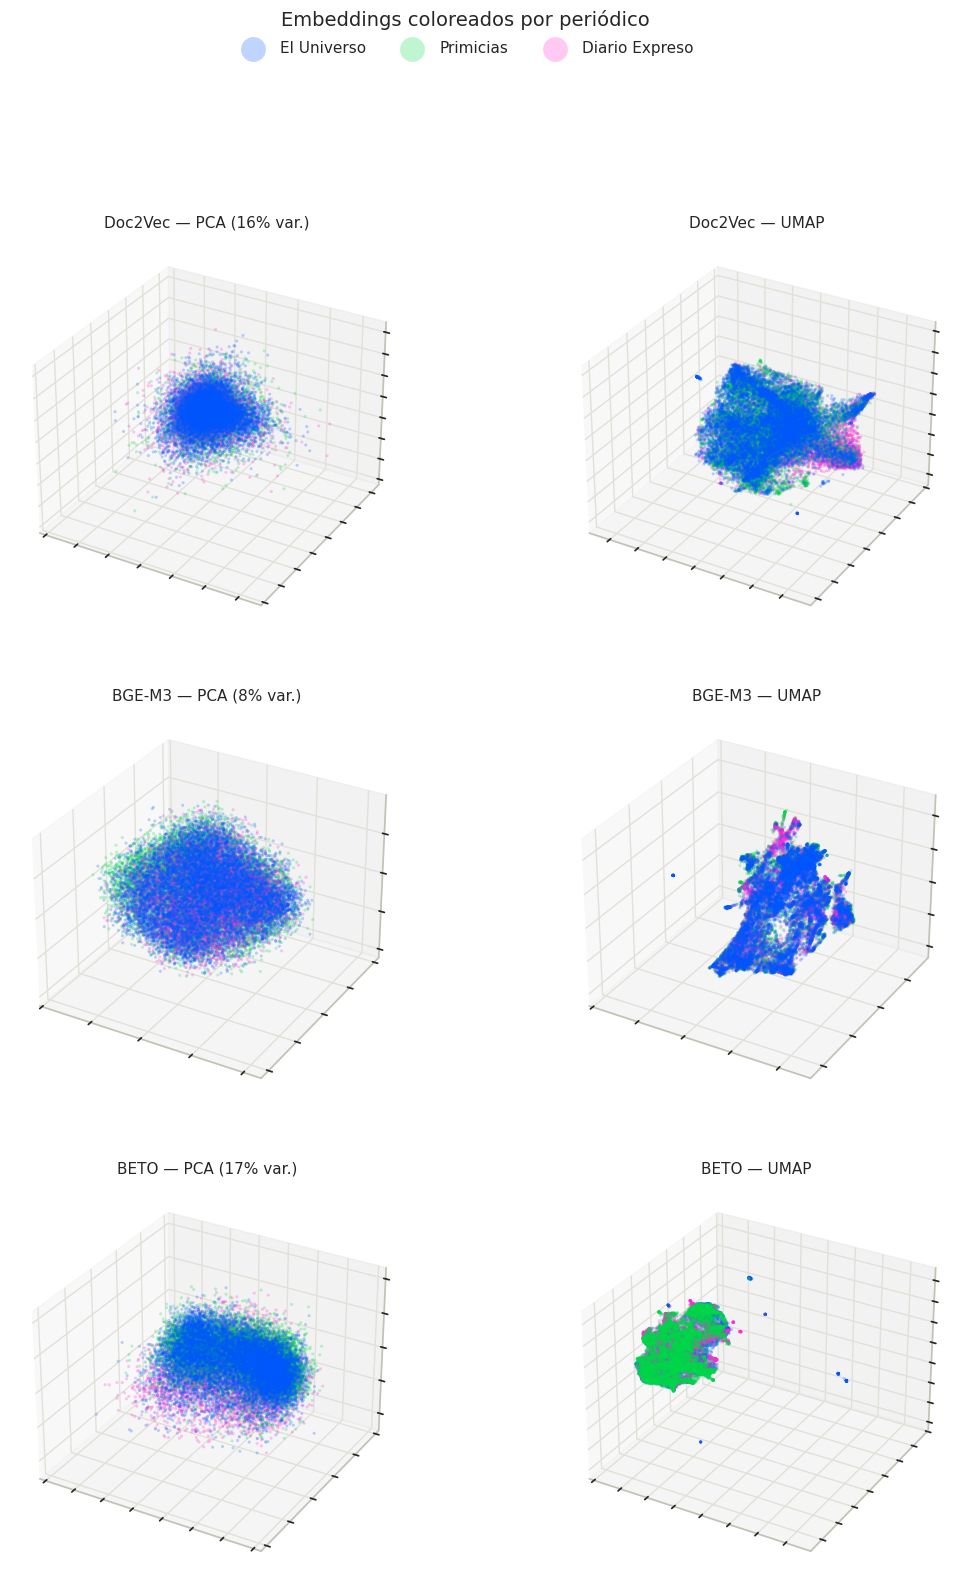

In [ ]:
def plot_proyecciones(color_por: str, titulo: str, colores: dict, etiquetas: dict):
    # Una fila por método: el número de filas se deriva de `proyecciones`, nunca fijo,
    # para que añadir un método no lo deje fuera del gráfico en silencio.
    nfilas = len(proyecciones)
    fig, axes = plt.subplots(nfilas, 2, figsize=(15, 5.8 * nfilas), squeeze=False,
                             subplot_kw={"projection": "3d"})
    for fila, (nombre, (xyz_pca, xyz_umap, var3)) in enumerate(proyecciones.items()):
        vistas = [(xyz_pca, f"PCA ({var3:.0%} var.)"), (xyz_umap, "UMAP")]
        for col, (xyz, tipo) in enumerate(vistas):
            ax = axes[fila, col]
            for valor, color in colores.items():
                mascara = (data[color_por] == valor).to_numpy()
                ax.scatter(xyz[mascara, 0], xyz[mascara, 1], xyz[mascara, 2],
                           s=5, alpha=0.25, color=color, label=etiquetas[valor],
                           linewidths=0)
            ax.set_title(f"{nombre} — {tipo}", fontsize=11)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_zticklabels([])
    handles, labels_leg = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper center", ncol=min(len(colores), 6),
               frameon=False, bbox_to_anchor=(0.5, 1.0), markerscale=8)
    fig.suptitle(titulo, y=1.01, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()


plot_proyecciones("nombre_periodico", "Embeddings coloreados por periódico",
                  dict(zip(orden_per, PALETA)), {p: p for p in orden_per})

Secciones destacadas: ['Deportes', 'Economía', 'Sociedad', 'Cultura', 'Mundo', 'Ciencia y Tecnología', 'Política', 'Local Guayaquil']


<ipython-input-276-bb31dc11f9d2>:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


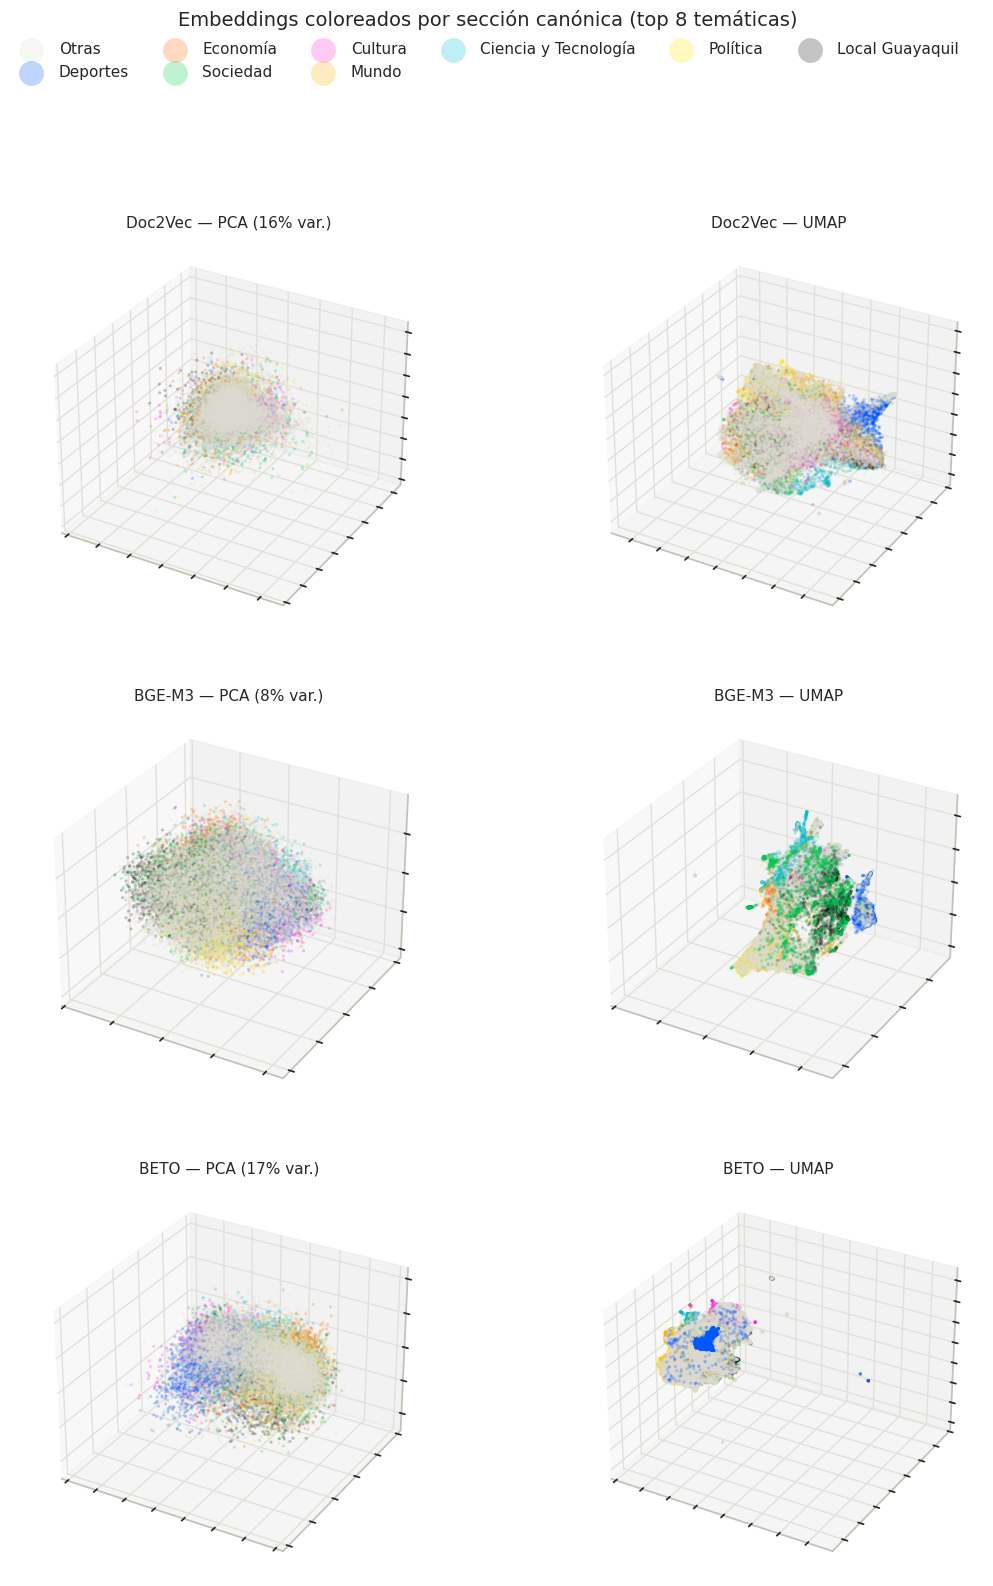

In [ ]:
# Colorear por sección canónica: las 8 clases temáticas más frecuentes; el resto va a
# "Otras" en gris de fondo (con 17 colores el gráfico deja de ser legible).
NO_TEMATICAS = {"Portada", "Opinión", "Actualidad", "Otros"}
top_secciones = (data.loc[~data["seccion_canonica"].isin(NO_TEMATICAS), "seccion_canonica"]
                 .value_counts().head(8).index.tolist())
print("Secciones destacadas:", top_secciones)

data["seccion_top"] = data["seccion_canonica"].where(
    data["seccion_canonica"].isin(top_secciones), "Otras")

# Paleta secundaria
PALETA_SEC = ["#0057ff", "#ff6a00", "#00c853", "#ff2bd6",
              "#ffb300", "#00bcd4", "#ffe600", "#111111"]
colores_sec = {"Otras": "#dedcd2", **dict(zip(top_secciones, PALETA_SEC))}

plot_proyecciones("seccion_top",
                  "Embeddings coloreados por sección canónica (top 8 temáticas)",
                  colores_sec, {v: v for v in colores_sec})

<ipython-input-276-bb31dc11f9d2>:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


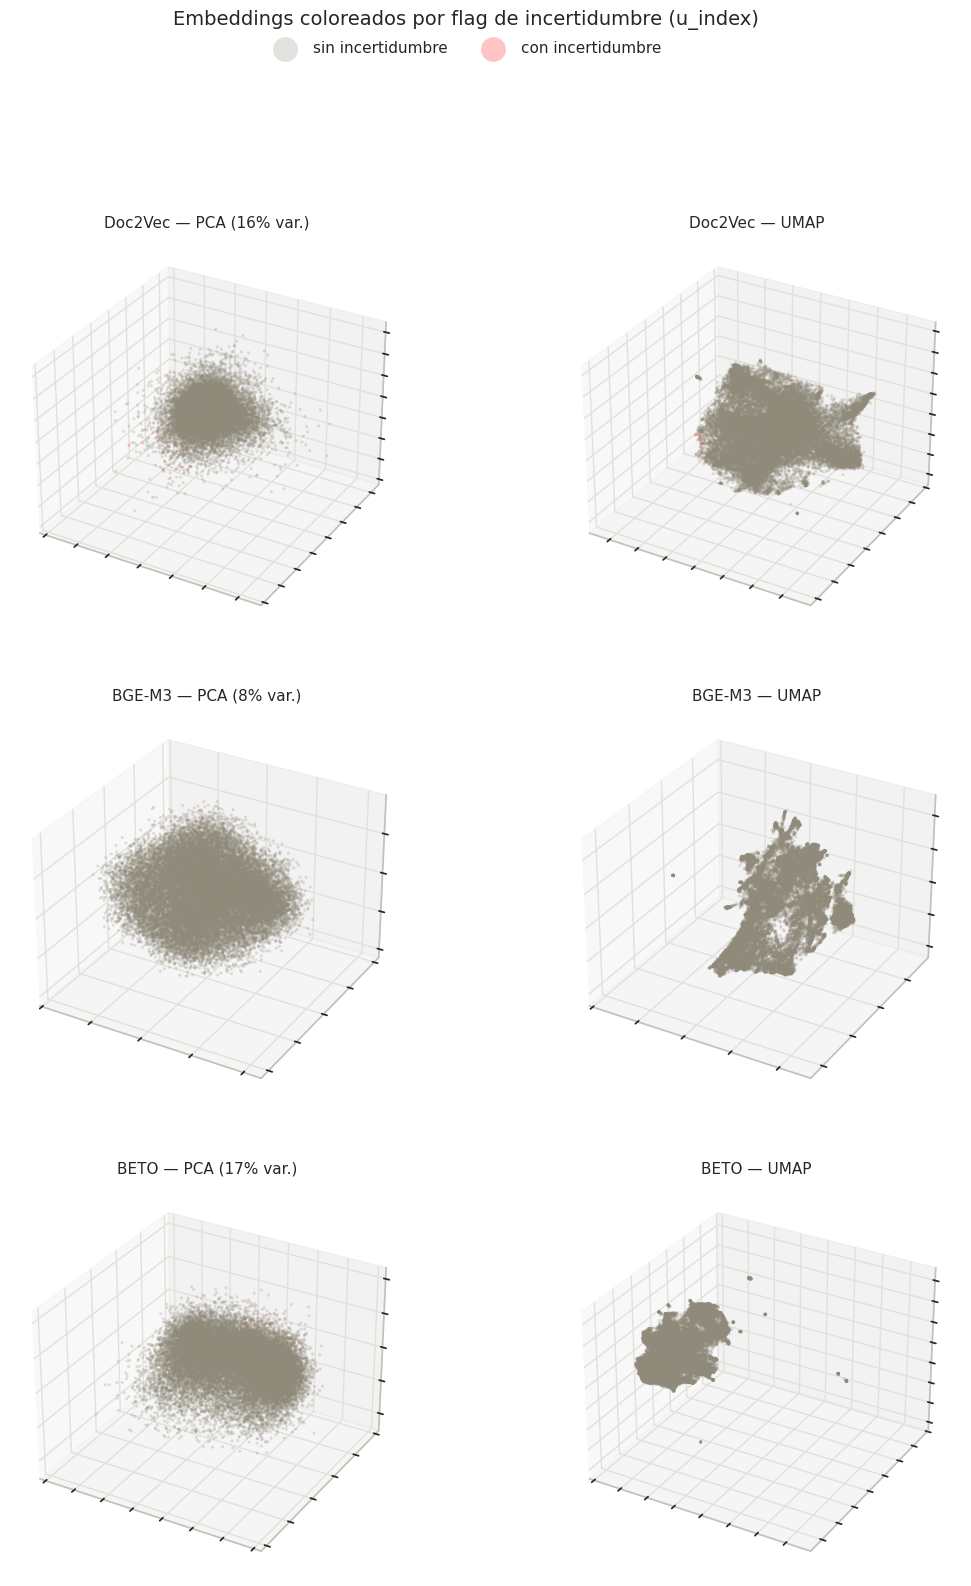

In [ ]:
plot_proyecciones("u_index", "Embeddings coloreados por flag de incertidumbre (u_index)",
                  COLOR_FLAG, {0: "sin incertidumbre", 1: "con incertidumbre"})

### Lectura de las proyecciones

- **Doc2Vec** se entrena sobre este mismo corpus, sin conocimiento externo: es el baseline
  distribucional. Con ~26k documentos ya tiene material suficiente (a diferencia de una
  submuestra de 1,500), así que sus agrupaciones son interpretables, pero siguen siendo
  co-ocurrencias de vocabulario, no semántica.
- **BGE-M3** procesa el artículo completo en un solo forward y tiene fine-tuning
  contrastivo: es el candidato natural para el pipeline de RAG con Milvus.
- **BETO** procesa el artículo entero vía chunking, pero es el único **sin fine-tuning
  contrastivo**: su espacio es anisotrópico (cosenos ~0.94 entre documentos arbitrarios),
  así que una nube compacta y sin estructura aparente puede ser geometría del espacio y no
  ausencia de contenido.
- Cuidado con la varianza explicada por el PCA de BETO: un porcentaje **alto** en 3
  componentes no es buena señal, sino el síntoma de esa dirección común dominante.
- Si los colores por periódico se mezclan dentro de los grupos, la estructura dominante es
  **temática** y no de medio — que es lo deseable para clustering de tópicos. Si en cambio
  los grupos coinciden con el periódico, el embedding está capturando estilo editorial.
- La vista por sección canónica es la lectura previa a la sección 4: si ahí ya se distinguen
  bloques de color, es esperable que HDBSCAN los recupere.


---
# 4. Clustering — HDBSCAN

**HDBSCAN** sobre cada método de embedding. Es basado en densidad, así que no exige fijar
`k` y admite que parte del corpus quede **sin clúster** (etiqueta `-1`, «ruido»), lo cual es
realista en prensa: muchos artículos no pertenecen a ningún tema recurrente.

Pipeline por método, idéntico para los tres para que la comparación sea limpia:

1. **L2-normalizar** el embedding ⇒ la distancia euclídea se vuelve monótona con la coseno.
2. **UMAP a 10 dimensiones** (`metric="cosine"`, `min_dist=0.0`). Con cientos de dimensiones
   la densidad se aplana (maldición de la dimensionalidad) y HDBSCAN degenera; `min_dist=0.0`
   favorece clústeres compactos, que es lo que interesa para clusterizar (no para mirar).
3. **HDBSCAN** sobre ese espacio, con métrica euclídea (el coseno ya se aplicó en el paso 1).

Se usa el paquete standalone `hdbscan` y no `sklearn.cluster.HDBSCAN` porque expone
`condensed_tree_`, `single_linkage_tree_` y `validity_index` (DBCV), que se usan abajo.

Todo el análisis por método queda encapsulado en una sola función, `analizar_espacio`, para
que la sección 5 (AE/VAE) pueda invocarla sobre cualquier espacio latente nuevo sin duplicar
código ni depender de globals de bucles.

## Jerarquía de métricas

El criterio no es "cuántas métricas puedo calcular" sino "cuáles deciden". Cuatro niveles,
y el código y los plots respetan esa jerarquía.

**Nivel 1 — deciden cuál embedding gana.** Van en los paneles del codo y en la tabla
principal.
- **AMI** contra `seccion_canonica` y contra `seccion`. Es la métrica externa principal.
- **DBCV** — la validación intrínseca diseñada para clustering por densidad: entiende el
  ruido y no penaliza formas no convexas.
- **Silhouette con distancia coseno** sobre el embedding original, **solo como benchmark
  relativo**. En espacios de 768–1024 dims un Silhouette coseno de **0.05–0.15 ya es un
  resultado decente**; no se compara contra el 0.6 de los ejemplos 2D de los libros de texto,
  donde las distancias no sufren de maldición de la dimensionalidad.
- **Coherencia NPMI** de los términos top por cluster.

**Nivel 2 — contexto obligatorio, nunca se leen las de nivel 1 sin estas al lado.**
`n_clusters`, `%_ruido`, `conf_media`, `pct_conf_baja`. Un embedding que manda el 70% de
los puntos a `-1` saca Silhouette alto trivialmente sobre el 30% restante.

**Nivel 3 — se reportan, no deciden.** ARI, NMI, V-Measure, homogeneidad, completitud,
coherencia $C_v$.

**Nivel 4 — anexo.** Davies-Bouldin, Calinski-Harabasz, Silhouette sobre UMAP-10.

### Por qué cada degradación

- **AMI, no NMI ni V-Measure.** NMI y V-Measure no corrigen por azar y **crecen
  mecánicamente con el número de clusters**. En un barrido tipo codo eso es activamente
  engañoso: la curva sube sola hacia los cortes más finos y llevaría a elegir la partición
  más fragmentada por artefacto matemático. AMI es la única de las tres comparable entre
  niveles con distinto k.
- **ARI se reporta, no decide.** Es demasiado estricta con la granularidad: si el modelo
  agrupa bien pero a un nivel de detalle distinto al de la taxonomía editorial, colapsa
  cerca de cero. Pero **no se elimina**: es la métrica más reportada en la literatura de
  clustering, y sobre todo la **brecha entre AMI alto y ARI bajo es la evidencia directa
  de que el modelo encontró subtemas coherentes dentro de las secciones** — que es
  justamente la hipótesis de este trabajo. Se usa como argumento, no como veredicto.
- **Homogeneidad por encima de completitud.** Para alimentar el RAG interesa que un
  cluster de 500 artículos hable de lo mismo. Si "Deportes" se parte en fútbol / tenis /
  ciclismo, la completitud cae y eso está bien. Se reportan las dos porque salen de la
  misma llamada y **completitud es la que demuestra que hubo fragmentación**.
- **Davies-Bouldin y Calinski-Harabasz al anexo.** El argumento habitual ("asumen esferas
  euclídeas y los embeddings de 1024 dims no lo son") **no aplica literalmente aquí**:
  este pipeline no las calcula sobre los 1024 dims sino sobre el UMAP-10, que es donde
  HDBSCAN clusteriza y donde la distancia euclídea sí es significativa. Las razones reales
  para no decidir con ellas son tres: (1) **CH crece casi monótonamente con k**, lo que la
  inutiliza en un gráfico de codo; (2) **DB está fuertemente correlacionada con el
  Silhouette calculado en ese mismo espacio**, así que no aporta información independiente;
  (3) HDBSCAN produce clusters no convexos incluso después de UMAP. Se siguen calculando
  (cuestan casi nada) y quedan en una tabla secundaria, para llegar a la comparación con el
  número **y** con el argumento de por qué no es el criterio.
- **Silhouette-UMAP al anexo.** Está inflado por construcción: UMAP separa grupos aunque
  la separación no exista en el espacio original. Se conserva solo para exhibir esa brecha
  frente al Silhouette coseno.

### Coherencia de tópicos

Es la única métrica que evalúa el **contenido textual** y no la geometría. Un cluster puede
tener silueta mediocre y ser semánticamente perfecto; la coherencia es la que dice si un
humano leería los términos top y reconocería el tema. Para un trabajo orientado a RAG es el
puente entre "los vectores se agrupan" y "los grupos sirven para recuperar".

- **NPMI como principal** (rango interpretable [-1, 1], más estable y más barata) y **$C_v$
  reportada al lado** porque es la que cita la literatura de topic modeling (LDA/BERTopic)
  y permite comparar con papers. $C_v$ tiene inestabilidades documentadas — por eso va en
  nivel 3, no en nivel 1.
- **Términos top por cluster con c-TF-IDF**: concatenar los documentos de cada cluster en
  un pseudo-documento, `TfidfVectorizer` sobre esos pseudo-documentos, top-10 términos por
  cluster. La componente IDF suprime sola las palabras ubicuas, así que no hace falta lista
  de stopwords.
- **Una sola tokenización para c-TF-IDF y para la coherencia.** Ambas usan el patrón por
  defecto de `TfidfVectorizer` (`\b\w\w+\b`) sobre `textos`, no el `texto.split()` con el
  que se entrena Doc2Vec en la celda 53. Es deliberado: con `.split()` los tokens del
  diccionario arrastrarían la puntuación pegada (`"gobierno,"` frente a `"gobierno"`), lo
  que partiría los conteos de una misma palabra entre varias entradas y hundiría las
  co-ocurrencias que NPMI mide. Compartir vocabulario por construcción es lo que hace que
  el número signifique algo.
- **Costo:** la coherencia se calcula solo en la partición EOM de cada método, no en cada
  nivel del barrido. `c_npmi` usa ventana deslizante sobre ~26k documentos; unas pocas
  llamadas son razonables, decenas (barrido × métodos) no lo son.

## Advertencia sobre las etiquetas externas

`seccion` y `seccion_canonica` son **labels ruidosos, no ground truth**: los asigna el
periódico por criterio editorial/maquetación, y `seccion_canonica` se deriva por
substring-matching sobre `seccion`. Un AMI/ARI bajo contra ellas es ambiguo por diseño: puede
significar que el clustering falló, o que encontró una estructura temática distinta (y
válida) a la de la sección editorial.

## Barrido por cortes del árbol

HDBSCAN no tiene un `k` que fijar: selecciona automáticamente la partición óptima (EOM,
*excess of mass*) sobre el árbol condensado. Para poder dibujar una curva tipo "codo" que
compare métodos con distinto número de clusters, se hace **un solo fit** de HDBSCAN y se
corta el `single_linkage_tree_` a distintas alturas (`get_clusters(cut_distance=d,
min_cluster_size=...)`). El eje X del barrido es entonces la **distancia de corte**
(equivalentemente, el nº de clusters que produce, tras deduplicar niveles que caen en el
mismo corte efectivo) — no un `k` elegido de antemano, que HDBSCAN no admite.

In [ ]:
# --- Constantes, corpus de coherencia y helpers de métricas ---
import hdbscan
from sklearn.preprocessing import normalize
from umap import UMAP
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score,
                             calinski_harabasz_score, davies_bouldin_score,
                             homogeneity_completeness_v_measure,
                             normalized_mutual_info_score, silhouette_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from IPython.display import display

MIN_CLUSTER_SIZE  = 100   # tamaño mínimo de un cluster "real"
MIN_SAMPLES       = 10    # mayor => más puntos marcados como ruido
N_MUESTRA_METRICA = 8000  # silhouette/DBCV necesitan la matriz de distancias completa
N_CORTES          = 12    # niveles del barrido de cortes del árbol; subir para la corrida final
TOP_TERMINOS      = 10    # términos c-TF-IDF por cluster
COLS_VERDAD       = ["seccion", "seccion_canonica"]   # etiquetas externas, ambas ruidosas

# Corpus de coherencia, construido UNA sola vez, con `_PATRON_TOKEN` (celda 50): el MISMO
# tokenizador que usan Doc2Vec y `terminos_por_cluster`. Que coincidan no es cosmético: la
# coherencia es una medida relacional entre los términos top de un cluster y los conteos de
# co-ocurrencia del corpus, así que si cada pieza llamara "palabra" a algo distinto el
# número no significaría nada. `textos` ya viene en minúsculas desde norm_text (celda 36).
tokens_coh = [_PATRON_TOKEN.findall(t) for t in textos]
dicc_coh = Dictionary(tokens_coh)
dicc_coh.filter_extremes(no_below=5, no_above=0.5)   # no_below=5 replica min_count=5 de Doc2Vec


def _descriptivas(labels):
    """n_clusters, %_ruido y tamaños de cluster. Nivel 2: contexto obligatorio."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = int((labels == -1).sum())
    tam = np.bincount(labels[labels >= 0]) if (labels >= 0).any() else np.array([0])
    return {
        "n_clusters": n_clusters,
        "%_ruido": 100 * n_ruido / len(labels),
        "tam_min": int(tam.min()), "tam_med": int(np.median(tam)), "tam_max": int(tam.max()),
    }


def _internas(X, emb_norm, labels, rng):
    """Silhouette/DB/CH sobre submuestra, excluyendo ruido.

    Nivel 1: `silhouette_cos` (embedding original, métrica coseno) — comparable entre
    métodos de distinta dimensión.
    Anexo (nivel 4): `silhouette_umap` (inflado por construcción, UMAP separa aunque no
    haya separación real), `davies_bouldin` y `calinski_harabasz`. Estas dos últimas se
    calculan sobre `X` (el UMAP-10 donde HDBSCAN clusteriza), no sobre `emb_norm`: son
    razones de dispersión pensadas para distancia euclídea y no admiten métrica coseno.
    """
    sin_ruido = labels != -1
    if sin_ruido.sum() < 2 or len(set(labels[sin_ruido])) < 2:
        return {}
    idx = np.flatnonzero(sin_ruido)
    if len(idx) > N_MUESTRA_METRICA:
        idx = rng.choice(idx, N_MUESTRA_METRICA, replace=False)
    y = labels[idx]
    if len(set(y)) < 2:
        return {}
    return {
        "silhouette_cos": silhouette_score(emb_norm[idx], y, metric="cosine"),
        "silhouette_umap": silhouette_score(X[idx], y),
        "davies_bouldin": davies_bouldin_score(X[idx], y),
        "calinski_harabasz": calinski_harabasz_score(X[idx], y),
    }


def _dbcv(X, labels, rng):
    """DBCV (validity_index) sobre submuestra; requiere float64 y matriz de distancias.

    Cambio respecto al código exploratorio previo: se excluye el ruido ANTES de
    submuestrear (antes se submuestreaba sobre todos los puntos, incluido el ruido), para
    que todas las internas (silhouette, DB, CH, DBCV) hablen del mismo subconjunto de
    puntos "clusterizados".
    """
    sin_ruido = labels != -1
    if sin_ruido.sum() < 2 or len(set(labels[sin_ruido])) < 2:
        return np.nan
    idx = np.flatnonzero(sin_ruido)
    if len(idx) > N_MUESTRA_METRICA:
        idx = rng.choice(idx, N_MUESTRA_METRICA, replace=False)
    y = labels[idx]
    if len(set(y) - {-1}) < 2:
        return np.nan
    try:
        return hdbscan.validity.validity_index(X[idx].astype(np.float64), y)
    except Exception as e:            # DBCV falla si un cluster queda con 1 punto
        print(f"  (DBCV no calculable: {e})")
        return np.nan


def _externas(labels, data, cols=COLS_VERDAD):
    """ARI/AMI/NMI/V/homogeneidad/completitud contra cada columna de `cols`.

    AMI_{col} es nivel 1 (decide); el resto es nivel 3 (se reporta, no decide).
    El ruido (-1) cuenta como una categoría más en `labels`, igual que antes: ignorarlo
    premiaría a los métodos que descartan lo difícil. No hay subdivisión 17/13 clases ni
    métrica de pureza: se eliminaron en este refactor.
    """
    salida = {}
    for col in cols:
        y_true = data[col].to_numpy()
        y_pred = labels
        h, c, v = homogeneity_completeness_v_measure(y_true, y_pred)
        salida[f"AMI_{col}"] = adjusted_mutual_info_score(y_true, y_pred)
        salida[f"ARI_{col}"] = adjusted_rand_score(y_true, y_pred)
        salida[f"NMI_{col}"] = normalized_mutual_info_score(y_true, y_pred)
        salida[f"V_{col}"] = v
        salida[f"homog_{col}"] = h
        salida[f"compl_{col}"] = c
    return salida


def terminos_por_cluster(labels, textos, top_n=TOP_TERMINOS):
    """c-TF-IDF: concatena los textos de cada cluster (sin ruido) en un pseudo-documento,
    vectoriza con TfidfVectorizer y devuelve los top_n términos por cluster ordenados por
    peso. La componente IDF suprime sola las palabras ubicuas, sin necesidad de stopwords.
    """
    clusters_validos = sorted(set(labels) - {-1})
    if not clusters_validos:
        return {}
    pseudo_docs = [
        " ".join(textos[i] for i in np.flatnonzero(labels == c))
        for c in clusters_validos
    ]
    vectorizador = TfidfVectorizer(max_features=20000)
    matriz = vectorizador.fit_transform(pseudo_docs)
    vocab = np.array(vectorizador.get_feature_names_out())

    resultado = {}
    for fila, c in enumerate(clusters_validos):
        pesos = matriz[fila].toarray().ravel()
        top_idx = np.argsort(pesos)[::-1][:top_n]
        resultado[c] = [vocab[i] for i in top_idx if pesos[i] > 0]
    return resultado


def _coherencia(terminos, tokens=tokens_coh, dicc=dicc_coh):
    """NPMI (principal, nivel 1) y C_v (nivel 3) sobre los términos top por cluster.

    Filtra los términos ausentes del diccionario de coherencia antes de pasarlos a gensim
    (revienta si un tópico queda vacío) y descarta tópicos que queden con <2 términos tras
    el filtro. Si no quedan tópicos válidos devuelve NaN en ambas.
    """
    topics = []
    for terms in terminos.values():
        filtrados = [t for t in terms if t in dicc.token2id]
        if len(filtrados) >= 2:
            topics.append(filtrados)

    if not topics:
        return {"npmi": np.nan, "cv": np.nan}

    try:
        npmi = CoherenceModel(topics=topics, texts=tokens, dictionary=dicc,
                              coherence="c_npmi").get_coherence()
    except Exception as e:
        print(f"  (NPMI no calculable: {e})")
        npmi = np.nan
    try:
        cv = CoherenceModel(topics=topics, texts=tokens, dictionary=dicc,
                            coherence="c_v").get_coherence()
    except Exception as e:
        print(f"  (C_v no calculable: {e})")
        cv = np.nan
    return {"npmi": npmi, "cv": cv}

In [ ]:
# --- Núcleo reutilizable: clustering + métricas + plots para un espacio de embedding ---
def analizar_espacio(emb, nombre, data, *,
                     min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES,
                     n_cortes=N_CORTES, coherencia=True, plots=True,
                     random_state=RANDOM_STATE) -> dict:
    """Corre el pipeline completo de clustering (L2-normalize -> UMAP-10 -> HDBSCAN),
    el barrido por cortes del árbol, el soft clustering y las métricas de las cuatro
    jerarquías sobre un único espacio de embedding `emb` [N, D].

    Diseñada para ser reutilizable desde la sección 5 (AE/VAE) sobre espacios latentes
    que no viven en `metodos`.
    """
    assert len(emb) == len(data), "El orden de emb y data no coincide."
    print(f"\n{'=' * 60}\n{nombre} — {np.asarray(emb).shape}\n{'=' * 60}")

    rng = np.random.default_rng(random_state)

    # --- 1-3. L2-normalize -> UMAP-10 (coseno) -> HDBSCAN (idéntico a la celda 65 original) ---
    emb_norm = normalize(emb)
    X = UMAP(n_components=10, n_neighbors=30, min_dist=0.0, metric="cosine",
             random_state=random_state).fit_transform(emb_norm)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
        gen_min_span_tree=True,
        prediction_data=True,       # necesario para soft clustering
    ).fit(X)
    labels_eom = clusterer.labels_

    n_clusters_eom = len(set(labels_eom)) - (1 if -1 in labels_eom else 0)
    n_ruido_eom = int((labels_eom == -1).sum())
    print(f"EOM — clusters: {n_clusters_eom}  |  ruido: {n_ruido_eom:,} "
          f"({n_ruido_eom / len(labels_eom):.1%})")
    if n_clusters_eom:
        tam = np.bincount(labels_eom[labels_eom >= 0])
        print(f"Tamaños — mín {tam.min()}, mediana {int(np.median(tam))}, máx {tam.max()}")

    # --- 4. Barrido de cortes del árbol ---
    tree_df = clusterer.single_linkage_tree_.to_pandas()
    distancias = tree_df["distance"].to_numpy()
    distancias = distancias[np.isfinite(distancias) & (distancias > 0)]

    cuantiles = np.linspace(0.50, 0.999, n_cortes)
    cortes_dist = np.quantile(distancias, cuantiles)

    filas_barrido = []
    n_clusters_vistos = set()
    for d in cortes_dist:
        labels_nivel = clusterer.single_linkage_tree_.get_clusters(
            cut_distance=d, min_cluster_size=min_cluster_size,
        )
        n_cl = len(set(labels_nivel)) - (1 if -1 in labels_nivel else 0)
        if n_cl < 2 or n_cl in n_clusters_vistos:
            continue   # deduplicar por n_clusters resultante; descartar niveles triviales
        n_clusters_vistos.add(n_cl)

        fila = {"metodo": nombre, "nivel": "corte", "distancia_corte": d}
        fila.update(_descriptivas(labels_nivel))
        fila.update(_internas(X, emb_norm, labels_nivel, rng))
        fila["dbcv"] = _dbcv(X, labels_nivel, rng)
        fila.update(_externas(labels_nivel, data))
        filas_barrido.append(fila)

    # Fila EOM, siempre incluida. Las métricas del EOM se calculan UNA sola vez aquí y se
    # reutilizan más abajo en `resumen`: recalcularlas duplicaría el coste (silhouette y
    # DBCV son O(n^2) sobre la submuestra) y, como `rng` avanza en cada llamada, la
    # submuestra sería otra y la MISMA partición daría dos valores distintos en la fila
    # del barrido y en la tabla comparativa.
    metricas_eom = {}
    metricas_eom.update(_descriptivas(labels_eom))
    metricas_eom.update(_internas(X, emb_norm, labels_eom, rng))
    metricas_eom["dbcv"] = _dbcv(X, labels_eom, rng)
    metricas_eom.update(_externas(labels_eom, data))

    fila_eom = {"metodo": nombre, "nivel": "eom", "distancia_corte": np.nan}
    fila_eom.update(metricas_eom)
    filas_barrido.append(fila_eom)

    barrido = pd.DataFrame(filas_barrido).sort_values("n_clusters").reset_index(drop=True)

    # --- 5. Soft clustering (diagnóstico de confianza, no reasignación de ruido) ---
    P = hdbscan.all_points_membership_vectors(clusterer)
    if P.ndim == 1:
        P = P[:, None]
    n_clusters_soft = P.shape[1]

    soft_df = pd.DataFrame(index=data.index)
    soft_df["cluster_duro"] = labels_eom
    soft_df["cluster_soft"] = P.argmax(axis=1)
    soft_df["membresia_max"] = P.max(axis=1)
    soft_df["fuerza_cluster_duro"] = clusterer.probabilities_

    masa = P.sum(axis=1)
    soft_df["masa_asignada"] = masa
    soft_df["masa_residual"] = np.clip(1 - masa, 0, 1)

    if n_clusters_soft >= 2:
        top2 = np.partition(P, -2, axis=1)[:, -2:]
        top2.sort(axis=1)
        soft_df["margen_top2"] = top2[:, 1] - top2[:, 0]

        P_condicional = np.divide(P, masa[:, None], out=np.zeros_like(P), where=masa[:, None] > 0)
        entropia = -np.sum(np.where(P_condicional > 0, P_condicional * np.log(P_condicional), 0), axis=1)
        soft_df["entropia_soft"] = entropia / np.log(n_clusters_soft)
    else:
        soft_df["margen_top2"] = np.nan
        soft_df["entropia_soft"] = np.nan

    no_ruido = labels_eom != -1
    conf_media = float(clusterer.probabilities_[no_ruido].mean()) if no_ruido.any() else np.nan
    pct_conf_baja = float(100 * np.mean(clusterer.probabilities_[no_ruido] < 0.5)) if no_ruido.any() else np.nan
    entropia_media = float(soft_df.loc[no_ruido, "entropia_soft"].mean()) if no_ruido.any() else np.nan

    # --- 6. Métricas de alta confianza (probabilities_ >= 0.5), sufijo _conf ---
    # Se toma el SUBCONJUNTO de puntos seguros, no se remapean los dudosos a ruido:
    # mandarlos a -1 crearía una categoría gigante que mezcla ruido genuino con puntos
    # simplemente ambiguos, y el AMI resultante ya no sería interpretable. Los puntos de
    # ruido quedan fuera solos, porque HDBSCAN les asigna probabilities_ = 0.
    alta_conf = clusterer.probabilities_ >= 0.5
    if alta_conf.sum() >= 2 and len(set(labels_eom[alta_conf]) - {-1}) >= 2:
        externas_conf = {
            f"{k}_conf": v
            for k, v in _externas(labels_eom[alta_conf], data.loc[alta_conf]).items()
            if k.startswith("AMI_") or k.startswith("ARI_")
        }
    else:
        externas_conf = {}

    # --- 7. Coherencia (solo sobre la partición EOM) ---
    terminos = terminos_por_cluster(labels_eom, textos) if (coherencia or plots) else {}
    coherencia_eom = _coherencia(terminos) if coherencia else {"npmi": np.nan, "cv": np.nan}

    # --- Resumen (fila que alimenta la tabla comparativa) ---
    resumen = {"metodo": nombre}
    resumen.update(metricas_eom)          # ya calculadas arriba, no se repiten
    resumen.update(externas_conf)
    resumen.update(coherencia_eom)
    resumen["conf_media"] = conf_media
    resumen["pct_conf_baja"] = pct_conf_baja
    resumen["entropia_media"] = entropia_media

    # --- 8. Plots ---
    if plots:
        barrido_ordenado = barrido.sort_values("n_clusters")
        eom_row = barrido_ordenado[barrido_ordenado["nivel"] == "eom"]

        # Figura A — codo, nivel 1 + 2
        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
        paneles_a = [
            ("silhouette_cos", "Silhouette (coseno) ↑"),
            ("dbcv", "DBCV ↑"),
            ("AMI_seccion_canonica", "AMI vs seccion_canonica ↑"),
            ("%_ruido", "% ruido"),
        ]
        for ax, (col, titulo) in zip(axes.ravel(), paneles_a):
            ax.plot(barrido_ordenado["n_clusters"], barrido_ordenado[col], marker="o", ms=3)
            if not eom_row.empty:
                ax.scatter(eom_row["n_clusters"], eom_row[col], color="red", zorder=5, label="EOM")
                ax.legend()
            ax.set_xlabel("n_clusters")
            ax.set_title(titulo)
        fig.suptitle(f"{nombre} — codo (nivel 1+2)", fontsize=13)
        plt.tight_layout()
        plt.show()

        # Figura B — nivel 3
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        axes[0].plot(barrido_ordenado["n_clusters"], barrido_ordenado["ARI_seccion_canonica"], marker="o", ms=3, label="ARI")
        axes[0].plot(barrido_ordenado["n_clusters"], barrido_ordenado["NMI_seccion_canonica"], marker="o", ms=3, label="NMI")
        axes[0].plot(barrido_ordenado["n_clusters"], barrido_ordenado["V_seccion_canonica"], marker="o", ms=3, label="V")
        axes[0].set_xlabel("n_clusters"); axes[0].set_title("ARI/NMI/V vs k"); axes[0].legend()

        axes[1].plot(barrido_ordenado["n_clusters"], barrido_ordenado["homog_seccion_canonica"], marker="o", ms=3, label="homogeneidad")
        axes[1].plot(barrido_ordenado["n_clusters"], barrido_ordenado["compl_seccion_canonica"], marker="o", ms=3, label="completitud")
        axes[1].set_xlabel("n_clusters"); axes[1].set_title("Homogeneidad vs completitud"); axes[1].legend()

        probs_no_ruido = clusterer.probabilities_[no_ruido]
        axes[2].hist(probs_no_ruido, bins=30, color="steelblue")
        axes[2].axvline(0.5, color="red", linestyle="--")
        axes[2].set_title("Distribución de probabilities_ (no ruido)")
        fig.suptitle(f"{nombre} — nivel 3", fontsize=13)
        plt.tight_layout()
        plt.show()

        # Figura C — anexo (nivel 4)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        axes[0].plot(barrido_ordenado["n_clusters"], barrido_ordenado["davies_bouldin"], marker="o", ms=3, color="darkorange")
        axes[0].set_xlabel("n_clusters"); axes[0].set_title("Davies-Bouldin (↓ mejor)")

        axes[1].plot(barrido_ordenado["n_clusters"], barrido_ordenado["calinski_harabasz"], marker="o", ms=3, color="seagreen")
        axes[1].set_xlabel("n_clusters"); axes[1].set_title("Calinski-Harabasz (↑ mejor)")

        axes[2].plot(barrido_ordenado["n_clusters"], barrido_ordenado["silhouette_umap"], marker="o", ms=3, label="silhouette UMAP")
        axes[2].plot(barrido_ordenado["n_clusters"], barrido_ordenado["silhouette_cos"], marker="o", ms=3, label="silhouette coseno")
        axes[2].set_xlabel("n_clusters"); axes[2].set_title("Silhouette: UMAP vs coseno"); axes[2].legend()
        fig.suptitle(f"{nombre} — anexo (nivel 4)", fontsize=13)
        plt.tight_layout()
        plt.show()

        # Figura D — scatter 2D (PCA-2 sobre X) de la partición EOM
        X_vis = PCA(n_components=2).fit_transform(X)
        ruido = labels_eom == -1
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(X_vis[ruido, 0], X_vis[ruido, 1], c="lightgray", s=5, alpha=0.25)
        ax.scatter(X_vis[~ruido, 0], X_vis[~ruido, 1], c=labels_eom[~ruido], cmap="tab20", s=7, alpha=0.70)
        ax.set_title(f"{nombre} — EOM: {n_clusters_eom} clusters · ruido {ruido.mean():.1%}")
        ax.set_xlabel("Componente visual 1"); ax.set_ylabel("Componente visual 2")
        plt.tight_layout()
        plt.show()

    return {
        "nombre": nombre, "labels": labels_eom, "clusterer": clusterer,
        "X": X, "emb_norm": emb_norm, "barrido": barrido, "soft_df": soft_df,
        "membership": P, "terminos": terminos, "resumen": resumen,
    }


Doc2Vec — (26210, 150)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


EOM — clusters: 16  |  ruido: 16,050 (61.2%)
Tamaños — mín 110, mediana 555, máx 1327


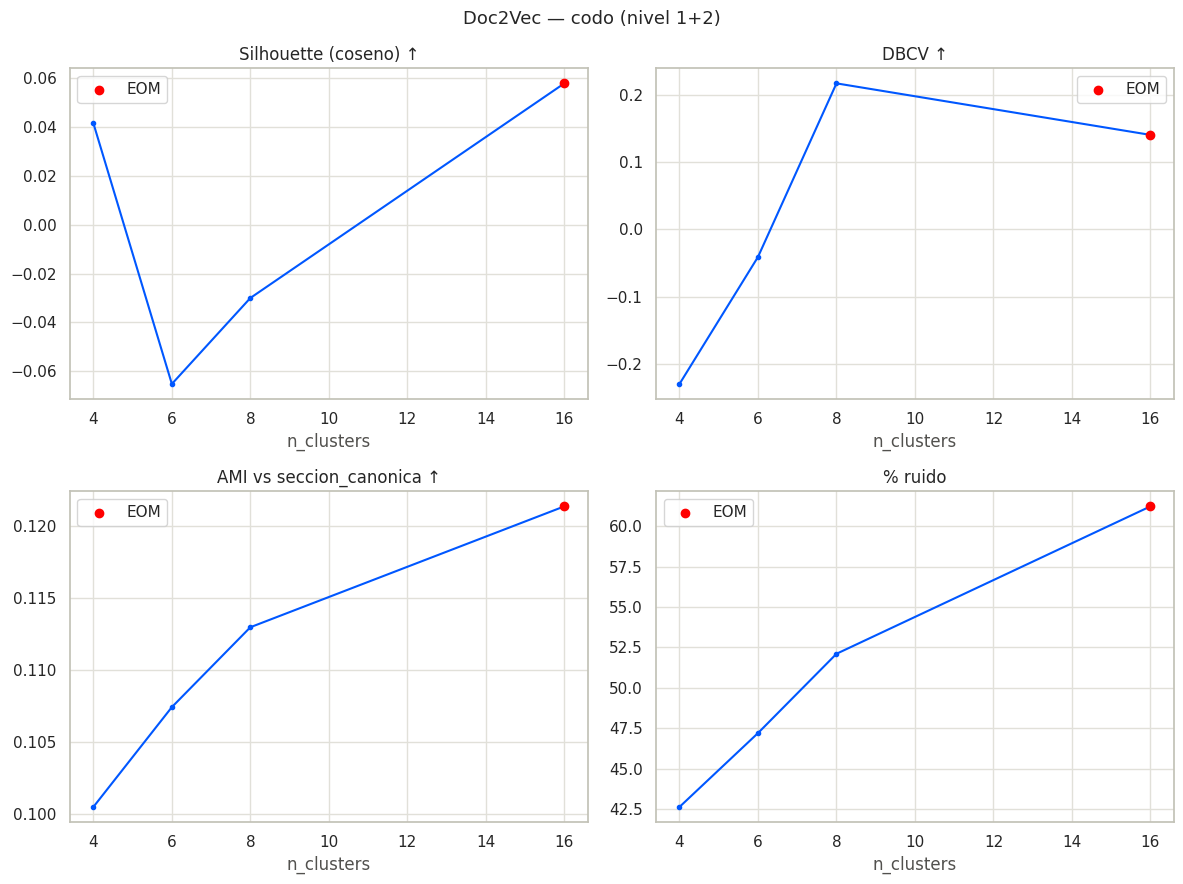

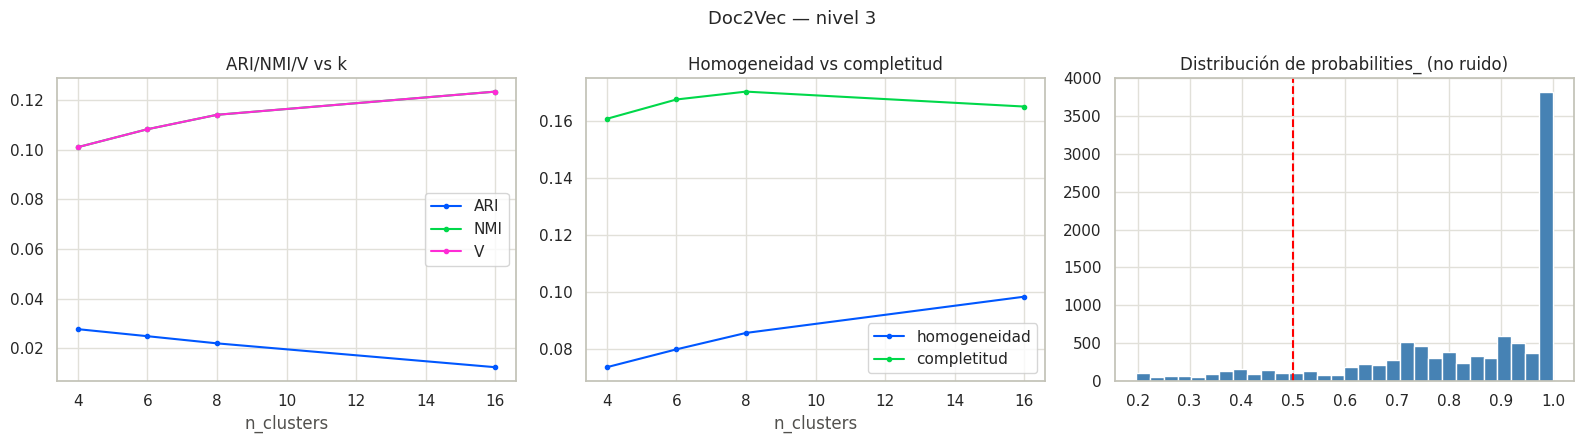

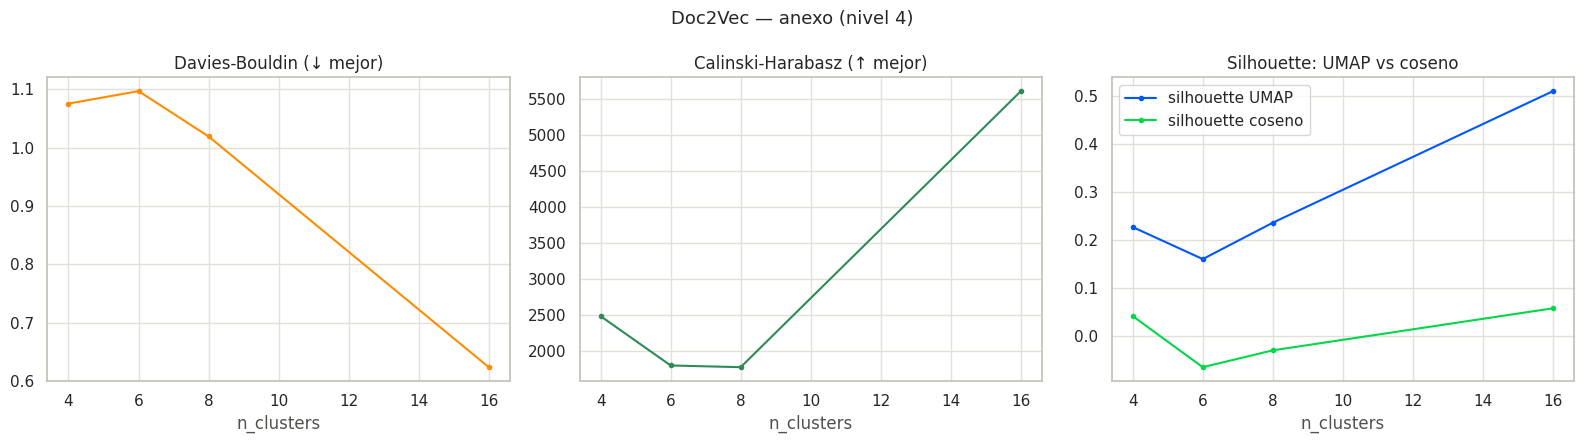

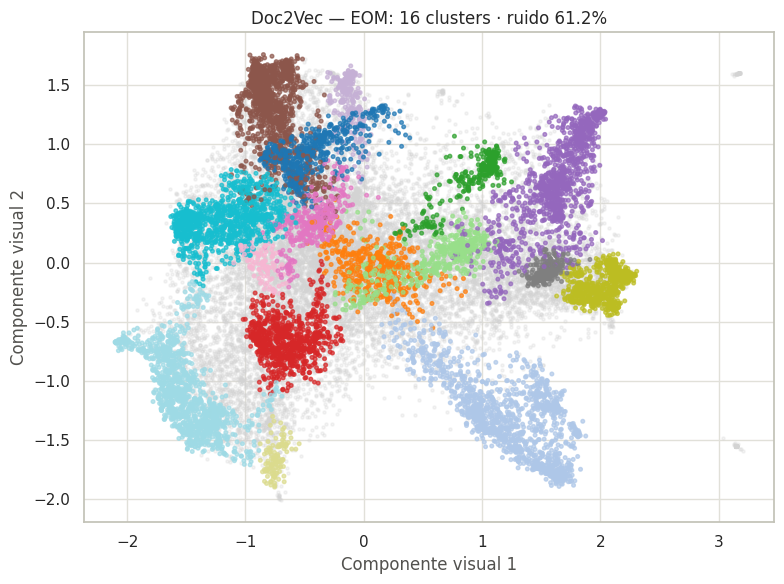


BGE-M3 — (26210, 1024)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


EOM — clusters: 43  |  ruido: 8,373 (31.9%)
Tamaños — mín 125, mediana 292, máx 2443


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


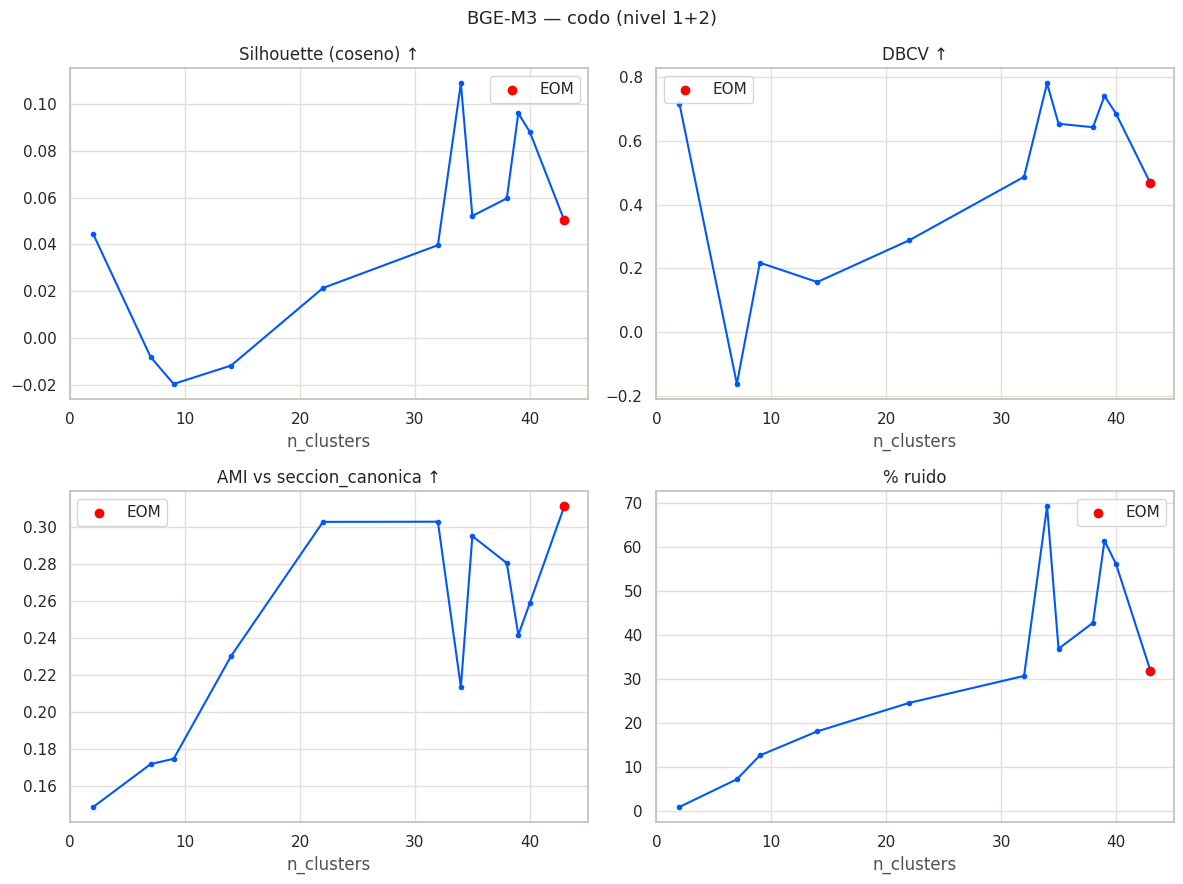

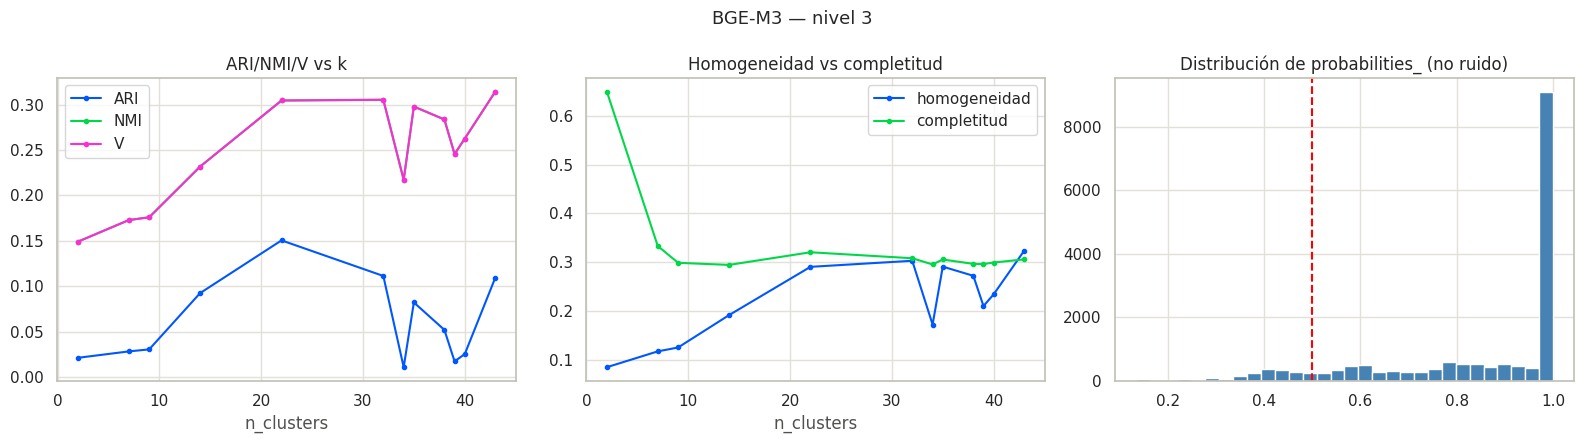

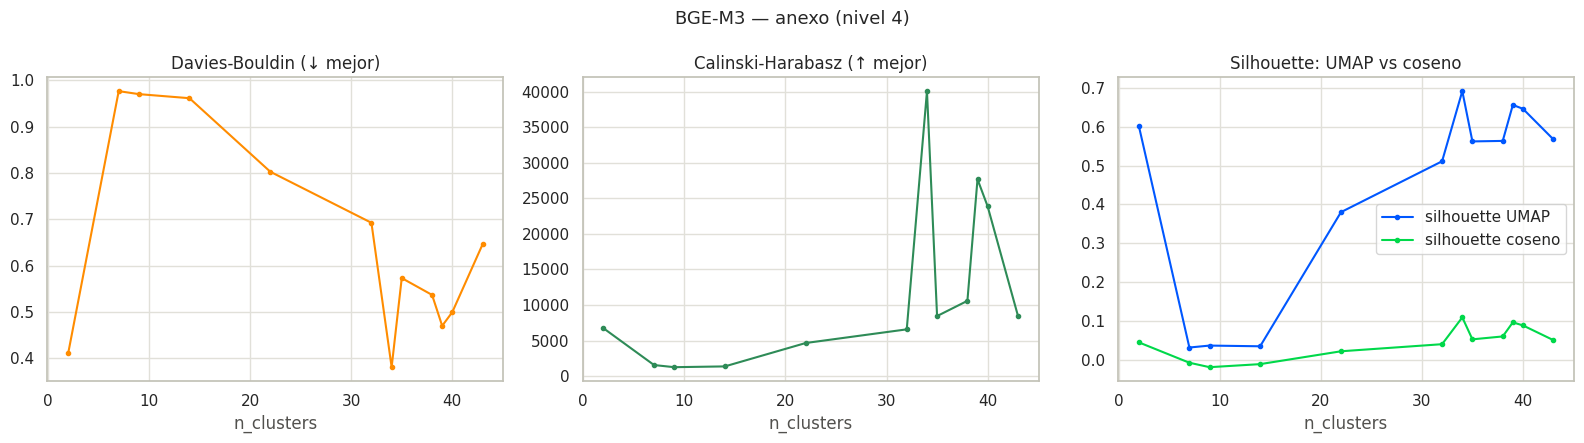

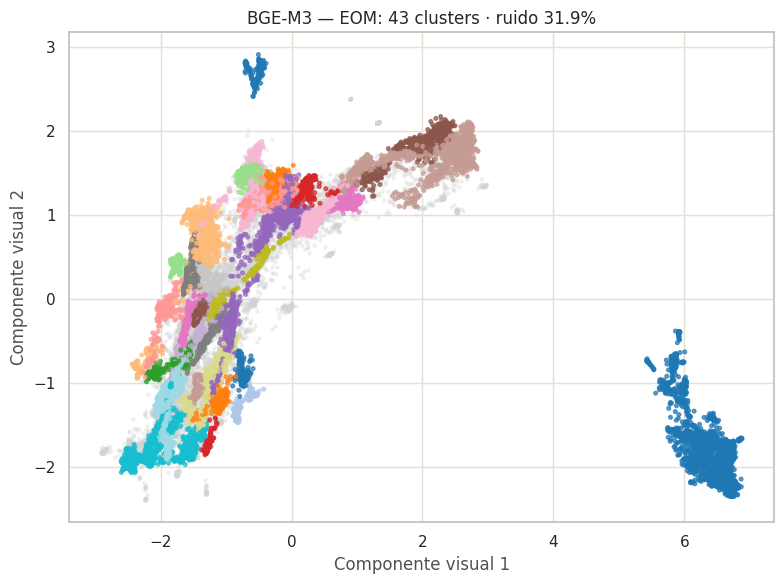


BETO — (26210, 768)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [ ]:
# Corre el pipeline completo sobre los tres métodos de embedding (Doc2Vec, BGE-M3, BETO).
# La sección 5 añade entradas nuevas a este mismo diccionario con espacios latentes AE/VAE.
resultados = {n: analizar_espacio(e, n, data) for n, e in metodos.items()}

In [ ]:
# --- Comparación entre espacios: tabla jerárquica y curvas superpuestas del barrido ---
def comparar_espacios(resultados: dict) -> pd.DataFrame:
    """Apila el `resumen` de cada espacio (indexado por método) y muestra tres tablas en
    orden de jerarquía: principal (nivel 1+2, decide), secundaria (nivel 3, se reporta) y
    anexo (nivel 4). Las columnas se seleccionan por intersección con las disponibles,
    porque `_internas` puede devolver `{}` (p. ej. si un espacio tiene <2 clusters).
    """
    filas = []
    for nombre, r in resultados.items():
        fila = dict(r["resumen"])
        fila["dims"] = r["emb_norm"].shape[1]   # NO metodos[nombre]: la sección 5 mete latentes
        filas.append(fila)
    df = pd.DataFrame(filas).set_index("metodo")

    cols_principal = ["dims", "n_clusters", "%_ruido", "tam_min", "tam_med", "tam_max",
                      "AMI_seccion", "AMI_seccion_canonica", "dbcv", "silhouette_cos", "npmi"]
    cols_secundaria = ["ARI_seccion", "ARI_seccion_canonica", "NMI_seccion", "NMI_seccion_canonica",
                       "V_seccion", "V_seccion_canonica", "homog_seccion", "homog_seccion_canonica",
                       "compl_seccion", "compl_seccion_canonica", "cv",
                       "conf_media", "pct_conf_baja", "entropia_media",
                       "AMI_seccion_conf", "AMI_seccion_canonica_conf",
                       "ARI_seccion_conf", "ARI_seccion_canonica_conf"]
    cols_anexo = ["davies_bouldin", "calinski_harabasz", "silhouette_umap"]

    print("Nivel 1+2 — principal: decide cuál embedding gana "
          "(AMI/DBCV/silhouette_cos/NPMI ↑ mejor; %_ruido es contexto, no se optimiza)")
    disponibles = [c for c in cols_principal if c in df.columns]
    display(df[disponibles].round(3))

    print("\nNivel 3 — secundaria: se reporta, no decide (ARI/NMI/V/homog/compl/C_v ↑ mejor)")
    disponibles = [c for c in cols_secundaria if c in df.columns]
    display(df[disponibles].round(3))

    print("\nNivel 4 — anexo (Davies-Bouldin ↓ mejor; Calinski-Harabasz y silhouette_umap "
          "↑ mejor pero inflados/no discriminantes, ver celda de jerarquía de métricas)")
    disponibles = [c for c in cols_anexo if c in df.columns]
    display(df[disponibles].round(3))

    return df


def plot_comparacion(resultados: dict) -> None:
    """Superpone las curvas del barrido de todos los métodos en la misma rejilla de
    paneles (una línea por método) — los mismos paneles que la figura A de
    `analizar_espacio`. Es el gráfico que responde la pregunta de qué embedding es mejor.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    paneles = [
        ("silhouette_cos", "Silhouette (coseno) ↑"),
        ("dbcv", "DBCV ↑"),
        ("AMI_seccion_canonica", "AMI vs seccion_canonica ↑"),
        ("%_ruido", "% ruido"),
    ]
    for ax, (col, titulo) in zip(axes.ravel(), paneles):
        for nombre, r in resultados.items():
            barrido = r["barrido"].sort_values("n_clusters")
            if col not in barrido.columns:
                continue
            ax.plot(barrido["n_clusters"], barrido[col], marker="o", ms=3, label=nombre)
        ax.set_xlabel("n_clusters")
        ax.set_title(titulo)
        ax.legend()
    fig.suptitle("Comparación entre espacios — barrido por cortes del árbol", fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Elección del ganador ---
metricas = comparar_espacios(resultados)
plot_comparacion(resultados)

MEJOR = metricas["AMI_seccion_canonica"].idxmax()

# Ganador por cada métrica de nivel 1, por separado: si no coinciden es un hallazgo, no
# un detalle que esconder (p. ej. AMI alto con NPMI bajo sugeriría clusters temáticamente
# distintos a la sección editorial pero semánticamente poco legibles, o viceversa).
criterios_nivel1 = {
    "AMI_seccion_canonica": "max",
    "dbcv": "max",
    "silhouette_cos": "max",
    "npmi": "max",
}
ganadores = {col: metricas[col].idxmax() for col in criterios_nivel1 if col in metricas.columns}

print(f"Criterio principal (AMI_seccion_canonica): MEJOR = {MEJOR}\n")
print("Ganador por cada métrica de nivel 1:")
for col, ganador in ganadores.items():
    marca = "" if ganador == MEJOR else "  <-- NO coincide con MEJOR"
    print(f"  {col:24s} -> {ganador}{marca}")

if len(set(ganadores.values())) > 1:
    print("\nLas métricas de nivel 1 NO coinciden en un único ganador: leer la tabla "
          "completa de comparar_espacios antes de descartar los demás métodos.")

## 4.6 — Inspección cualitativa del método ganador

A partir de aquí todo corre **solo sobre `MEJOR`**, no sobre los tres métodos: esto ya no es
la comparación cuantitativa de las secciones anteriores sino análisis interpretativo —
composición de cada cluster, artículos que quedaron en ruido, ambigüedad del soft
clustering y, opcionalmente, titulado con un LLM. Los términos c-TF-IDF que aparecen abajo
son la lectura humana que acompaña al NPMI de la tabla comparativa: NPMI dice si los
términos top son estadísticamente coherentes, pero solo leyéndolos se sabe si describen un
tema reconocible.

In [ ]:
def resumir_clusters(labels, data, terminos=None):
    tabla = pd.DataFrame({
        "cluster": labels,
        "seccion": data["seccion_canonica"].to_numpy(),
    })

    tabla = tabla[tabla["cluster"] != -1]

    filas = []

    for cluster_id, grupo in tabla.groupby("cluster"):
        conteos = grupo["seccion"].value_counts()
        seccion_principal = conteos.index[0]

        fila = {
            "cluster": cluster_id,
            "n_articulos": len(grupo),
            "seccion_dominante": seccion_principal,
            "pureza_seccion": conteos.iloc[0] / len(grupo),
            "n_secciones": conteos.size,
            "pct_sec_over_total_sec": conteos.size / tabla["seccion"].nunique(),
        }
        if terminos is not None:
            fila["terminos_top"] = ", ".join(terminos.get(cluster_id, []))
        filas.append(fila)

    return (
        pd.DataFrame(filas)
        .sort_values("n_articulos", ascending=False)
        .reset_index(drop=True)
    )

In [ ]:
print(f"Resumen de clusters — método ganador: {MEJOR}")
with pd.option_context("display.max_colwidth", 120):
    display(resumir_clusters(resultados[MEJOR]["labels"], data, resultados[MEJOR]["terminos"]))

In [ ]:
# Matriz cluster x sección canónica del mejor método según AMI sobre las clases temáticas.
# Normalizada por fila: cada celda es el % del cluster que cae en esa sección, así que una
# fila concentrada en una columna significa un cluster temáticamente puro.
labels_mejor = resultados[MEJOR]["labels"]
cruce = pd.crosstab(pd.Series(labels_mejor, name="cluster"),
                    pd.Series(data["seccion_canonica"].to_numpy(), name="seccion_canonica"), normalize="index") * 100

fig, ax = plt.subplots(figsize=(13, max(4, 0.32 * len(cruce))))
sns.heatmap(cruce, cmap="Blues", vmin=0, vmax=100, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "% del cluster"}, ax=ax)
ax.set_title(f"{MEJOR} — composición de cada cluster por sección canónica "
             f"(fila -1 = ruido)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Árbol condensado de HDBSCAN, la viz canónica del algoritmo: el grosor de cada rama es
# proporcional al nº de puntos y las elipses marcan los clusters seleccionados. No se
# reajusta nada: el clusterer se creó con gen_min_span_tree=True.
r = resultados[MEJOR]
n_cl = len(set(r["labels"]) - {-1})
if n_cl < 1:
    print(f"{MEJOR}: sin clusters, se omite el árbol")
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    r["clusterer"].condensed_tree_.plot(
        select_clusters=True,
        selection_palette=sns.color_palette("tab20", n_cl),
        axis=ax,
    )
    ax.set_title(f"{MEJOR} — árbol condensado (λ = 1/distancia; ramas ∝ nº de puntos)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
soft_df = resultados[MEJOR]["soft_df"]

columnas_texto = [
    c for c in ["titulo", "texto_norm", "seccion_canonica"]
    if c in data.columns
]

analisis_articulos = data[columnas_texto].join(
    soft_df[[
        "cluster_duro",
        "cluster_soft",
        "fuerza_cluster_duro",
        "membresia_max",
        "margen_top2",
        "entropia_soft",
        "masa_residual",
    ]]
)
display(
  analisis_articulos
  .query("cluster_duro == -1")
  .sort_values("masa_residual", ascending=False)
  .head(20)
)

In [ ]:
P = resultados[MEJOR]["membership"]
soft_df = resultados[MEJOR]["soft_df"]

# Excluimos ruido muy distante y escogemos artículos con mayor entropía
candidatos = soft_df[
    (soft_df["cluster_duro"] != -1) &
    (soft_df["masa_asignada"] > 0.20)
].nlargest(30, "entropia_soft")

idx_pos = data.index.get_indexer(candidatos.index)
P_ambiguos = P[idx_pos]

# Mostrar solo clusters relevantes para esos artículos
clusters_relevantes = np.where(P_ambiguos.max(axis=0) > 0.05)[0]

plt.figure(figsize=(12, 9))
sns.heatmap(
    P_ambiguos[:, clusters_relevantes],
    cmap="viridis",
    xticklabels=[f"C{k}" for k in clusters_relevantes],
    yticklabels=candidatos.index,
    vmin=0,
    vmax=1,
)
plt.title(f"{MEJOR} — membresía suave de los artículos más ambiguos")
plt.xlabel("Cluster")
plt.ylabel("Artículo")
plt.tight_layout()
plt.show()

### Nombrar los clústeres con un LLM (opcional)

Pide a DeepSeek un título descriptivo por clúster a partir de una muestra de sus artículos.
**Requiere VPN GlobalProtect activa** y consume tokens del servidor de la universidad, así
que se ejecuta para un solo método (`METODO_TITULAR`), no para los tres.

In [ ]:
# %% Nombrar cada cluster con DeepSeek (mismo patrón que hc_clustering.ipynb)
from src.llm_clients import get_chat_client, load_config
from tqdm.auto import tqdm

METODO_TITULAR = MEJOR          # cámbialo si quieres titular otro método
labels_tit = resultados[METODO_TITULAR]["labels"]
seccion_verdad = data["seccion_canonica"].to_numpy()

config = load_config()
cliente_chat = get_chat_client(config)
N_EJEMPLOS = 300

PROMPT_TITULO = (
    "Eres un analista de prensa ecuatoriana. A continuación tienes el TEXTO COMPLETO de "
    "de varios artículos de prensa que un algoritmo de clustering no supervisado agrupó en un mismo clúster. Es una muestra real: "
    "puede contener ruido (artículos que no encajan del todo) y texto repetido de plantilla "
    "(créditos de foto, firmas, llamados a suscripción) que debes ignorar al identificar el tema.\n\n"
    "{ejemplos}\n\n"
    "Instrucciones:\n"
    "1. Identifica el tema dominante por FRECUENCIA a lo largo de todos los artículos, no por "
    "el primero que aparece ni por un caso aislado o llamativo.\n"
    "2. Si hay un subtema minoritario claro (p. ej. una minoría de artículos de otro tipo), "
    "ignóralo salvo que sea tan grande que el clúster sea realmente heterogéneo.\n"
    "3. Si el clúster es heterogéneo (sin tema dominante claro), dilo explícitamente en el "
    "título (p. ej. 'Actualidad general: política, deportes y sucesos').\n"
    "4. Prefiere nombrar entidades, eventos o instituciones concretas (nombres propios, "
    "instituciones, tipo de delito, sector económico) sobre descripciones genéricas.\n\n"
    "Escribe UN solo título descriptivo en español (máximo 10 palabras) que resuma el tema "
    "dominante del clúster. Responde únicamente con el título, sin comillas ni explicaciones."
)

def titular_cluster(indices: np.ndarray) -> str:
    """Pide a DeepSeek un título descriptivo para los artículos indicados (posiciones en `data`)."""
    ejemplos = "\n".join(
        f"- {data.iloc[i]['titulo'] or '(sin título)'}: {data.iloc[i]['texto_norm']}"
        for i in indices
    )
    respuesta = cliente_chat.chat.completions.create(
        model=config.chat_model,
        messages=[{"role": "user", "content": PROMPT_TITULO.format(ejemplos=ejemplos)}],
        temperature=0.3,
        max_tokens=2000,  # modelo de razonamiento: reserva presupuesto para 'reasoning'
    )
    contenido = respuesta.choices[0].message.content
    return contenido.strip().strip('"') if contenido else "(respuesta vacía)"


rng_tit = np.random.default_rng(RANDOM_STATE)
filas_titulos = []
for c in tqdm(sorted(set(labels_tit) - {-1}), desc=f"Titulando ({METODO_TITULAR})"):
    indices = np.flatnonzero(labels_tit == c)
    seleccion = rng_tit.choice(indices, size=min(N_EJEMPLOS, len(indices)), replace=False)
    filas_titulos.append({
        "cluster": int(c),
        "n_articulos": len(indices),
        "seccion_dominante": pd.Series(seccion_verdad[indices]).value_counts().index[0],
        "titulo_deepseek": titular_cluster(seleccion),
    })

titulos_clusters = pd.DataFrame(filas_titulos)
# Mapa cluster -> título, con etiqueta explícita para el ruido
nombre_cluster = dict(zip(titulos_clusters["cluster"], titulos_clusters["titulo_deepseek"]))
nombre_cluster[-1] = "Ruido (sin clúster)"
with pd.option_context("display.max_colwidth", 120):
    display(titulos_clusters.sort_values("n_articulos", ascending=False))

In [ ]:
# %% Graficar los clusters en 2D (UMAP) con los nombres de DeepSeek
# Proyección 2D solo para la viz, independiente del UMAP-10 usado para clusterizar.
xy = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="cosine",
          random_state=RANDOM_STATE).fit_transform(resultados[METODO_TITULAR]["emb_norm"])

fig, ax = plt.subplots(figsize=(13, 10))
clusters_validos = sorted(set(labels_tit) - {-1})
cmap = plt.get_cmap("tab20", max(len(clusters_validos), 1))

# Ruido primero, en gris de fondo
mask_ruido = labels_tit == -1
ax.scatter(xy[mask_ruido, 0], xy[mask_ruido, 1], s=3, c="#c3c2b7",
           alpha=0.25, linewidths=0, label="_nolegend_")

for j, c in enumerate(clusters_validos):
    m = labels_tit == c
    color = cmap(j)
    ax.scatter(xy[m, 0], xy[m, 1], s=5, color=color, alpha=0.5, linewidths=0)
    # Etiqueta el cluster en su centroide (título recortado para que quepa)
    cx, cy = xy[m, 0].mean(), xy[m, 1].mean()
    etiqueta = nombre_cluster.get(c, str(c))
    ax.annotate(f"{c}: {etiqueta[:38]}", (cx, cy), fontsize=8, fontweight="bold",
                ha="center", va="center", color="#2b2b2b",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.85))

ax.set_xticks([]); ax.set_yticks([])
n_ruido = int(mask_ruido.sum())
ax.set_title(f"{METODO_TITULAR} — HDBSCAN sobre {len(labels_tit):,} artículos: "
             f"{len(clusters_validos)} clústeres + {n_ruido:,} en ruido "
             f"({n_ruido / len(labels_tit):.0%})", fontsize=12)
plt.tight_layout()
plt.show()

---
# 5. AE / VAE — reducción de dimensión (exploratorio)

Autoencoder / VAE puramente feed-forward (sin secuencia ni attention pooling): recibe
**cualquier** matriz de embeddings `[N, D]` y comprime a `latent_dim`, para aplicarse por
igual a Doc2Vec, BGE-M3 y BETO. El AE aprende una compresión determinista; el VAE una
distribución latente regularizada con KL (se usa `mu` para clusterizar, más estable que una
muestra). Luego se clusteriza el latente con el mismo HDBSCAN de la sección 4.

**Ahora sí entra en el pipeline:** los latentes se evalúan con `analizar_espacio`, igual que
los tres embeddings crudos, y entran en la misma tabla comparativa de la sección 4. Aviso
metodológico: los latentes se entrenan sobre `emb_beto` con `StandardScaler`, y luego
`analizar_espacio` les aplica `normalize` + UMAP coseno — el coseno sobre un espacio
estandarizado no significa lo mismo que sobre un embedding L2-normalizado, así que la
comparación AE/VAE vs. embeddings crudos es **indicativa, no estrictamente pareja**.

In [ ]:
# --- AE / VAE (MLP) generico: opera sobre cualquier embedding [N, D] ---
import lightning as L
import torch
import torch.nn as nn
import torch.nn.functional as F
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler


class MLPAutoencoder(L.LightningModule):
    """AE (variational=False) o VAE (True) feed-forward. hidden_dims define el encoder;
    el decoder es su espejo. Reconstruye el vector de entrada (no una secuencia)."""

    def __init__(self, input_dim, hidden_dims=(256,), latent_dim=64, variational=False,
                 dropout=0.0, lr=1e-3, weight_decay=1e-5,
                 beta=0.1, beta_max=1.0, beta_warmup_steps=0):
        super().__init__()
        self.save_hyperparameters()

        def bloque(i, o):
            return [nn.Linear(i, o), nn.GELU(), nn.Dropout(dropout)]

        enc_dims = [input_dim, *hidden_dims]
        self.encoder = nn.Sequential(
            *[capa for i, o in zip(enc_dims[:-1], enc_dims[1:]) for capa in bloque(i, o)]
        )
        ultimo = enc_dims[-1]
        if variational:
            self.to_mu = nn.Linear(ultimo, latent_dim)
            self.to_logvar = nn.Linear(ultimo, latent_dim)
        else:
            self.to_latent = nn.Linear(ultimo, latent_dim)

        dec_dims = [latent_dim, *reversed(hidden_dims)]
        capas = [c for i, o in zip(dec_dims[:-1], dec_dims[1:]) for c in bloque(i, o)]
        capas.append(nn.Linear(dec_dims[-1], input_dim))
        self.decoder = nn.Sequential(*capas)

    def _encode(self, x):
        h = self.encoder(x)
        if self.hparams.variational:
            mu, logvar = self.to_mu(h), self.to_logvar(h)
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)  # reparametrizacion
            return z, mu, logvar
        return self.to_latent(h), None, None

    def forward(self, x):
        z, mu, logvar = self._encode(x)
        return self.decoder(z), z, mu, logvar

    def _beta(self):
        if not self.hparams.variational:
            return 0.0
        if self.hparams.beta_warmup_steps <= 0:
            return self.hparams.beta
        p = min(1.0, self.global_step / float(self.hparams.beta_warmup_steps))
        return self.hparams.beta + p * (self.hparams.beta_max - self.hparams.beta)  # KL annealing

    def _step(self, batch, stage):
        x = batch[0]
        recon, z, mu, logvar = self(x)
        recon_loss = F.mse_loss(recon, x)
        if self.hparams.variational:
            kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
            loss = recon_loss + self._beta() * kl
            self.log(f"{stage}_kl", kl, on_step=False, on_epoch=True)
        else:
            loss = recon_loss
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._step(batch, "val")

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        _, z, mu, _ = self(batch[0])
        return (mu if self.hparams.variational else z).detach().cpu()  # mu: mas estable para clustering

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr,
                                weight_decay=self.hparams.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}


def entrenar_autoencoder(emb, variational=False, latent_dim=64, hidden_dims=(256,),
                         max_epochs=50, batch_size=128, lr=1e-3, beta=0.05,
                         beta_warmup_steps=500, estandarizar=True, seed=42):
    """Entrena un AE/VAE MLP sobre `emb` [N, D] y devuelve los latentes [N, latent_dim] en
    el MISMO orden que `emb` (latentes[i] <-> emb[i]), listos para GMM/KMeans."""
    X = np.asarray(emb, dtype=np.float32)
    if estandarizar:
        X = StandardScaler().fit_transform(X).astype(np.float32)  # cada metodo tiene su escala
    X = torch.from_numpy(X)

    ds = TensorDataset(X)
    n_val = max(1, int(0.1 * len(ds)))
    tr, va = random_split(ds, [len(ds) - n_val, n_val],
                          generator=torch.Generator().manual_seed(seed))
    dl_tr = DataLoader(tr, batch_size=batch_size, shuffle=True)
    dl_va = DataLoader(va, batch_size=batch_size)
    dl_full = DataLoader(ds, batch_size=batch_size)  # shuffle=False -> conserva el orden

    modelo = MLPAutoencoder(input_dim=X.shape[1], hidden_dims=hidden_dims, latent_dim=latent_dim,
                            variational=variational, lr=lr, beta=beta,
                            beta_warmup_steps=beta_warmup_steps if variational else 0)
    trainer = Trainer(
        max_epochs=max_epochs, accelerator="auto", devices=1,  # 1 proceso: DDP no corre en notebook y fragmentaria predict
        precision="16-mixed" if torch.cuda.is_available() else "32-true",
        logger=False, enable_checkpointing=False,
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, mode="min")],
    )
    trainer.fit(modelo, dl_tr, dl_va)
    return torch.cat(trainer.predict(modelo, dl_full), dim=0).numpy()

In [ ]:
# Aplicar a cualquiera de los metodos (cada emb_* es [N, D]). Ajusta latent_dim/hidden_dims/beta por metodo.
lat_beto_ae  = entrenar_autoencoder(emb_beto, variational=False)
lat_beto_vae = entrenar_autoencoder(emb_beto, variational=True, beta=0.05)
print("BETO  AE:", lat_beto_ae.shape, " VAE:", lat_beto_vae.shape)

# Cuando tengas emb_bge / emb_d2v para TODOS los textos, mismo patron:
# lat_bge_vae = entrenar_autoencoder(emb_bge, variational=True)
# lat_d2v_ae  = entrenar_autoencoder(emb_d2v, variational=False)

# Clustering sobre el latente (ejemplo):
# from sklearn.mixture import GaussianMixture
# labels = GaussianMixture(n_components=10, covariance_type="full",
#                          random_state=42).fit_predict(lat_beto_vae)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ Sequential │  196 K │ train │     0 │
│ 1 │ to_latent │ Linear     │ 16.4 K │ train │     0 │
│ 2 │ decoder   │ Sequential │  214 K │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 427 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 427 K                                                                                                
Total estimated model params size (MB): 1.709                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.

...

/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.

/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

BETO  AE: (26210, 64)  VAE: (26210, 64)


In [ ]:
# Mete los latentes AE/VAE en la misma tabla que los tres embeddings crudos: analizar_espacio
# corre el mismo pipeline (HDBSCAN + métricas) sobre lat_beto_ae/lat_beto_vae, así que
# metricas se recalcula desde cero (ahora con 5 filas, no 3).
resultados["BETO-AE"]  = analizar_espacio(lat_beto_ae,  "BETO-AE",  data)
resultados["BETO-VAE"] = analizar_espacio(lat_beto_vae, "BETO-VAE", data)

metricas = comparar_espacios(resultados)
plot_comparacion(resultados)